1.	Load the Titanic dataset using Python's pandas library.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
data_train=pd.read_csv(r"C:\Users\HP\Downloads\XGBM & LGBM\XGBM & LGBM\Titanic_train.csv")
data_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2.	Check for missing values.

In [2]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
data_train["Cabin"].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [4]:
data_train_1=data_train.drop(["PassengerId","Name","Ticket"],axis=1)
data_train_1

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


3.	Explore data distributions using histograms and box plots.

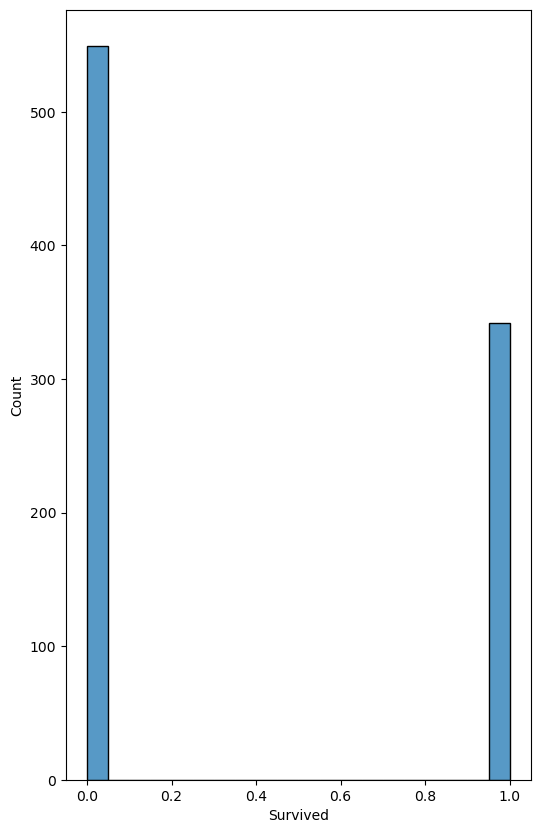

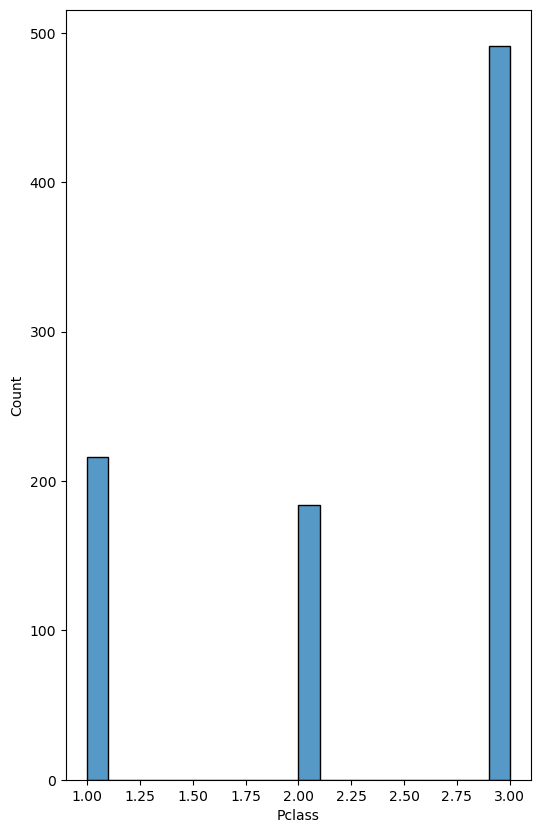

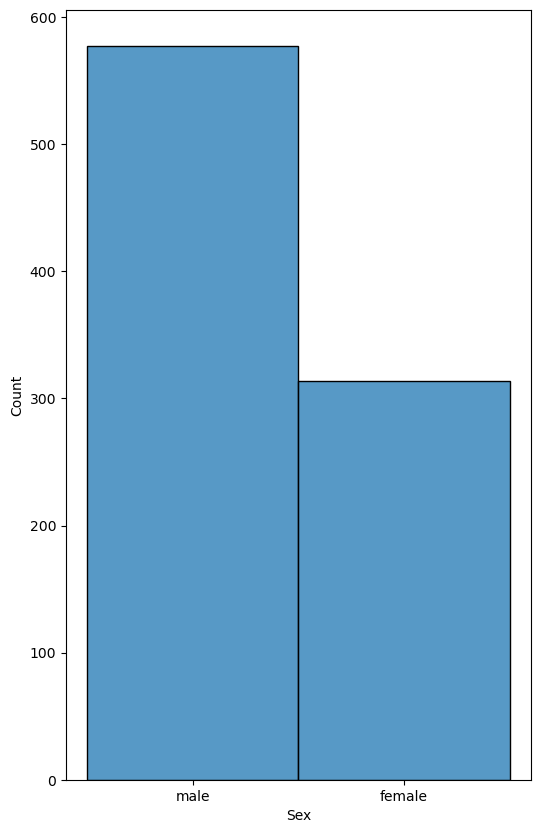

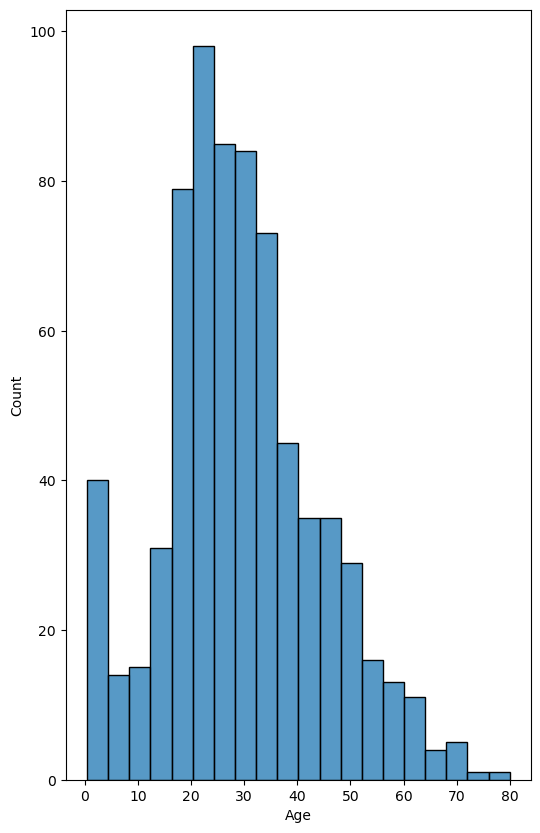

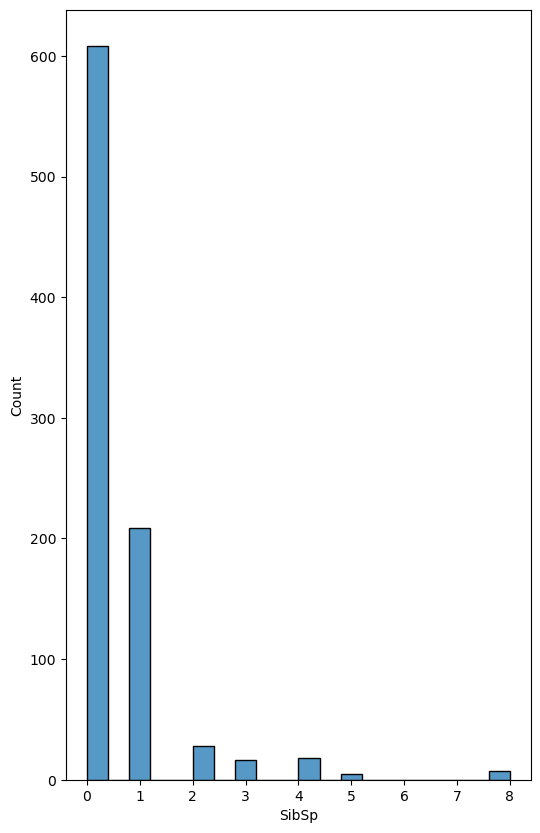

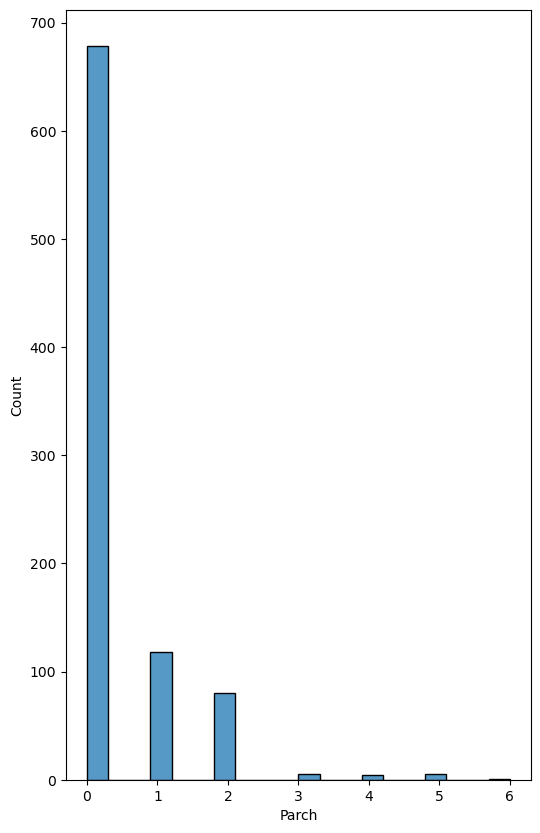

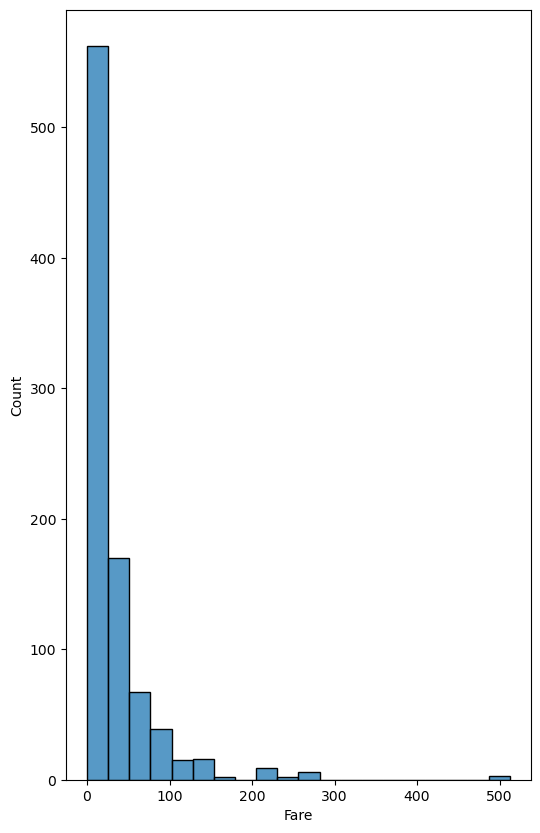

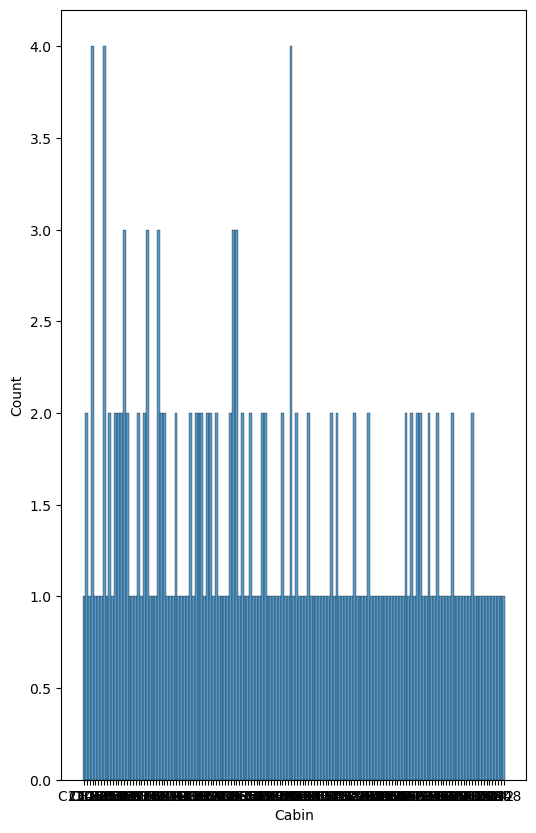

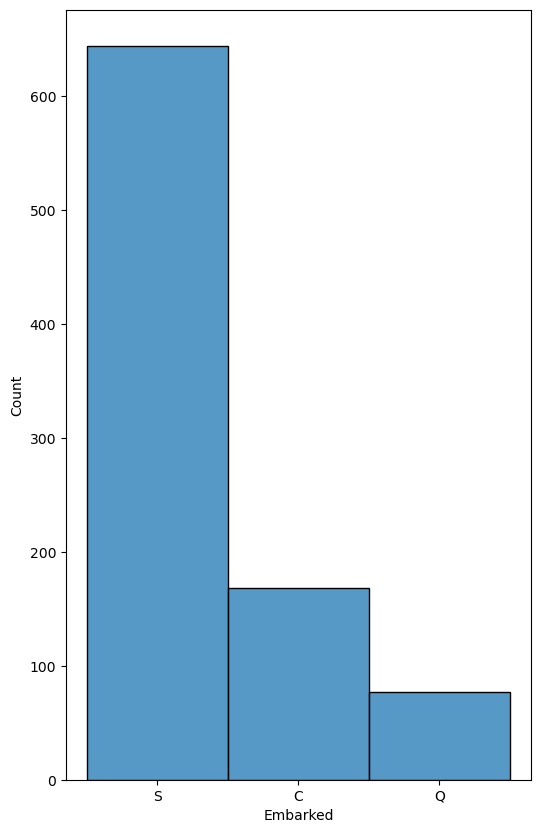

In [5]:
n=len(data_train_1.columns)
for i in range(0,n):
    plt.figure(figsize=[6,10])
    sns.histplot(data_train_1[data_train_1.columns[i]],bins=20)
    plt.show()

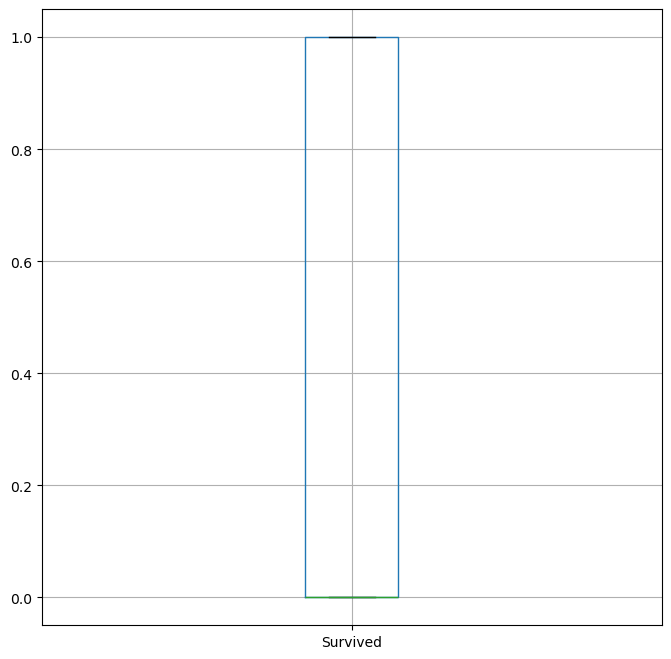

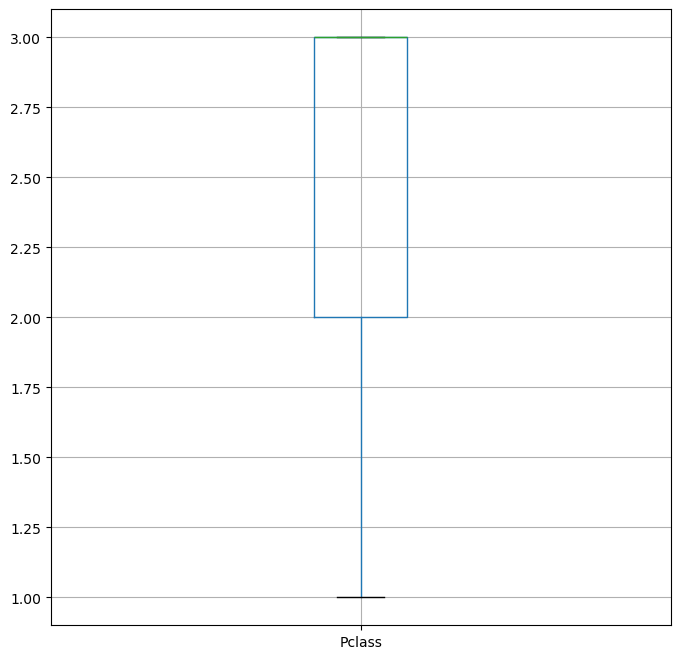

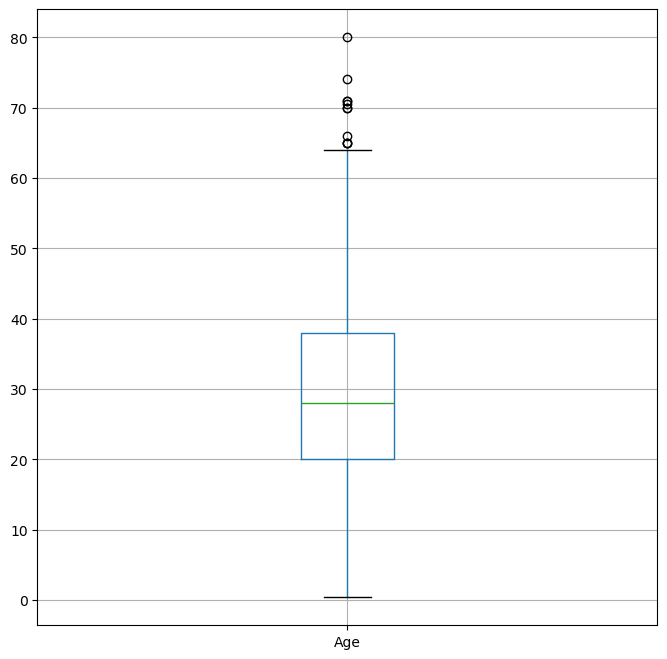

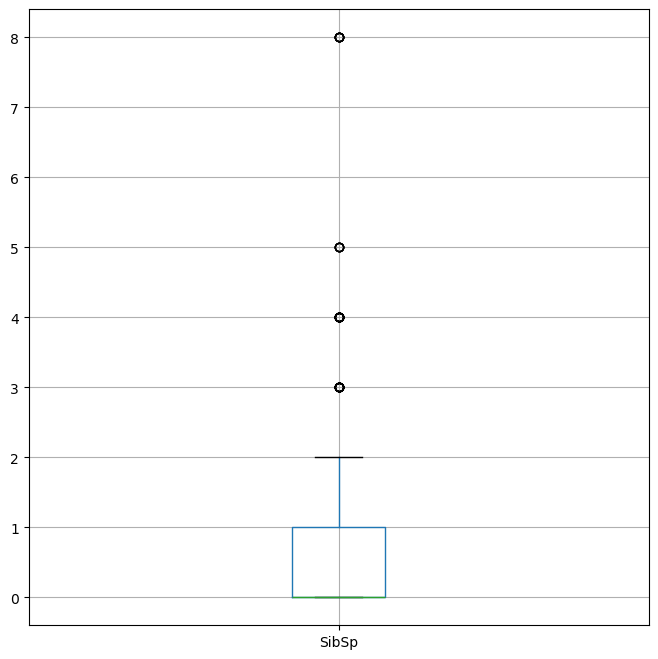

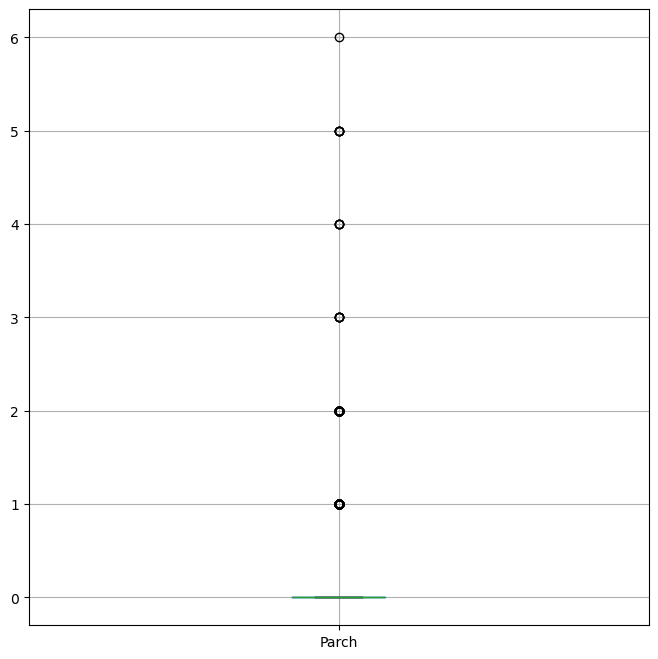

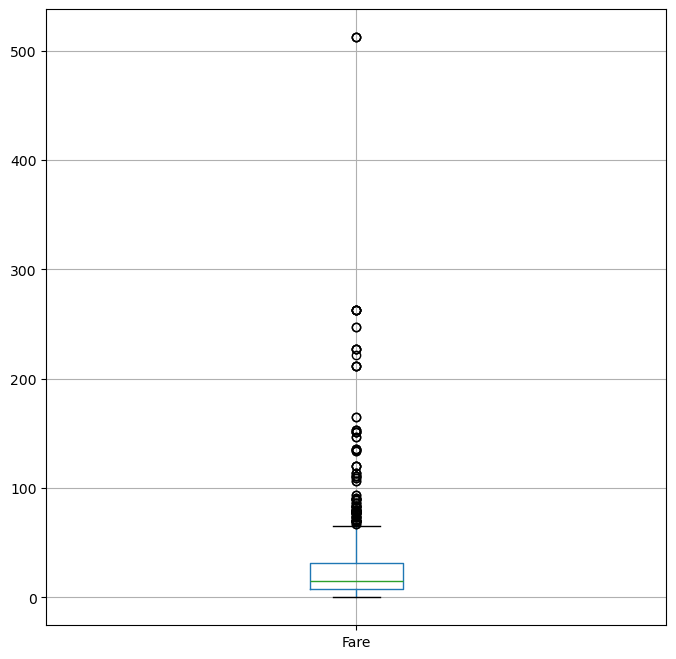

In [6]:
data_train_num_cols=data_train_1.select_dtypes(include=["int64","float64"])
n=len(data_train_num_cols.columns)
for i in range (0,n):
    plt.figure(figsize=[8,8])
    data_train_num_cols.boxplot(column=[data_train_num_cols.columns[i]])
    plt.show()

4.	Visualize relationships between features and survival using scatter plots and bar plots.

C:\Users\HP\AppData\Local\Temp\ipykernel_26900\3912083297.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=data_train_1, palette='viridis')


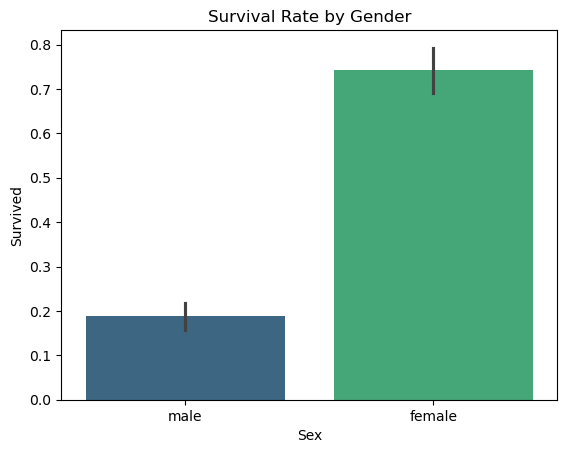

In [7]:
sns.barplot(x='Sex', y='Survived', data=data_train_1, palette='viridis')
plt.title('Survival Rate by Gender')
plt.show()

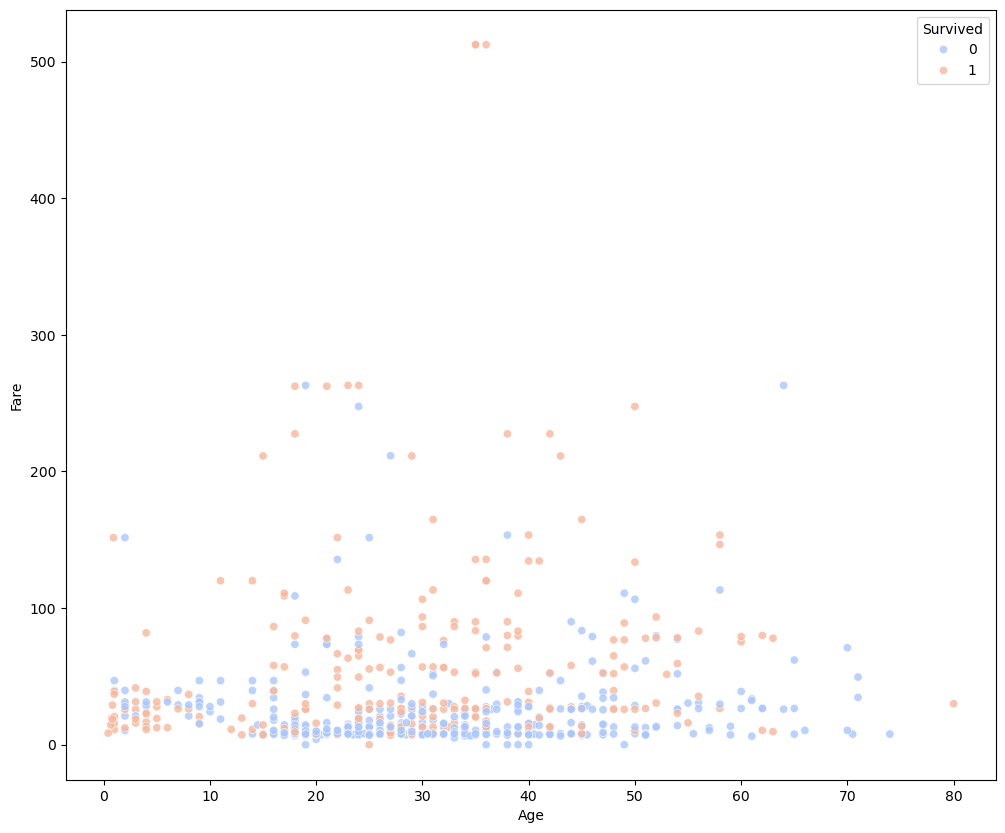

In [8]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x='Age', y='Fare', hue='Survived',data=data_train_1, palette='coolwarm', alpha=0.8)
#plt.title('')
plt.show()

1.	Impute missing values.
2.	Encode categorical variables using one-hot encoding or label encoding. 
3.	If needed you can apply more preprocessing methods on the given dataset.

In [9]:
print(data_train_1.isnull().sum())
median_age = data_train_1['Age'].median()
median_fare=data_train_1["Fare"].median()
data_train_1["Age"]=data_train_1["Age"].fillna(median_age)
data_train_1["Fare"]=data_train_1["Fare"].fillna(median_fare)
data_train_1.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [10]:
data_train_1['Deck'] = data_train_1['Cabin'].str[0]
data_train_1['Deck']=data_train_1['Deck'].fillna('U')
data_train_1['Deck']

0      U
1      C
2      U
3      C
4      U
      ..
886    U
887    B
888    U
889    C
890    U
Name: Deck, Length: 891, dtype: object

In [11]:
data_train_1['Family count']=data_train_1["SibSp"]+data_train_1["Parch"]+1
data_train_1['Family count']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Family count, Length: 891, dtype: int64

In [12]:
data_train_1=data_train_1.drop(["Cabin","SibSp","Parch"],axis=1)
data_train_1

,Survived,Pclass,Sex,Age,Fare,Embarked,Deck,Family count
0,0,3,male,22.0,7.2500,S,U,2
1,1,1,female,38.0,71.2833,C,C,2
2,1,3,female,26.0,7.9250,S,U,1
3,1,1,female,35.0,53.1000,S,C,2
4,0,3,male,35.0,8.0500,S,U,1
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,U,1
887,1,1,female,19.0,30.0000,S,B,1
888,0,3,female,28.0,23.4500,S,U,4
889,1,1,male,26.0,30.0000,C,C,1


In [13]:
data_train_1=pd.get_dummies(data_train_1, columns=["Pclass","Sex","Deck","Embarked"],drop_first=True, dtype=int)
data_train_1

,Survived,Age,Fare,Family count,Pclass_2,Pclass_3,Sex_male,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Embarked_Q,Embarked_S
0,0,22.0,7.2500,2,0,1,1,0,0,0,0,0,0,0,1,0,1
1,1,38.0,71.2833,2,0,0,0,0,1,0,0,0,0,0,0,0,0
2,1,26.0,7.9250,1,0,1,0,0,0,0,0,0,0,0,1,0,1
3,1,35.0,53.1000,2,0,0,0,0,1,0,0,0,0,0,0,0,1
4,0,35.0,8.0500,1,0,1,1,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,13.0000,1,1,0,1,0,0,0,0,0,0,0,1,0,1
887,1,19.0,30.0000,1,0,0,0,1,0,0,0,0,0,0,0,0,1
888,0,28.0,23.4500,4,0,1,0,0,0,0,0,0,0,0,1,0,1
889,1,26.0,30.0000,1,0,0,1,0,1,0,0,0,0,0,0,0,0


In [14]:
data_train_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    int64  
 1   Age           891 non-null    float64
 2   Fare          891 non-null    float64
 3   Family count  891 non-null    int64  
 4   Pclass_2      891 non-null    int64  
 5   Pclass_3      891 non-null    int64  
 6   Sex_male      891 non-null    int64  
 7   Deck_B        891 non-null    int64  
 8   Deck_C        891 non-null    int64  
 9   Deck_D        891 non-null    int64  
 10  Deck_E        891 non-null    int64  
 11  Deck_F        891 non-null    int64  
 12  Deck_G        891 non-null    int64  
 13  Deck_T        891 non-null    int64  
 14  Deck_U        891 non-null    int64  
 15  Embarked_Q    891 non-null    int64  
 16  Embarked_S    891 non-null    int64  
dtypes: float64(2), int64(15)
memory usage: 118.5 KB


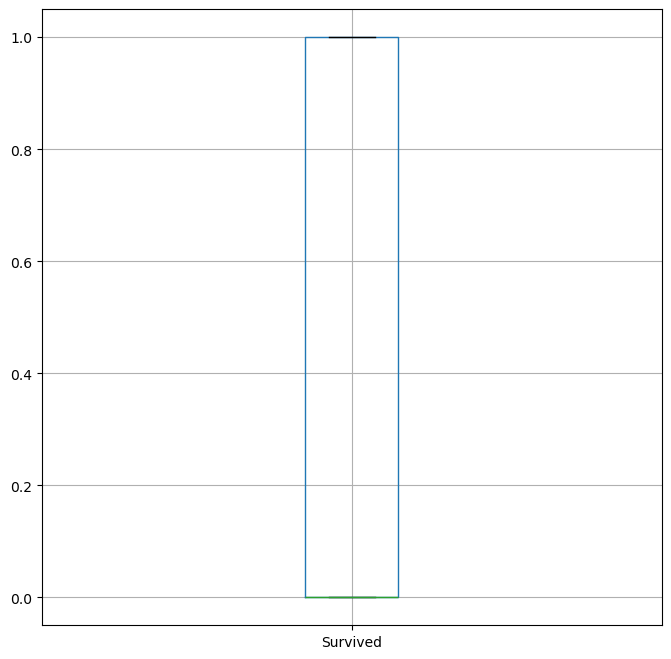

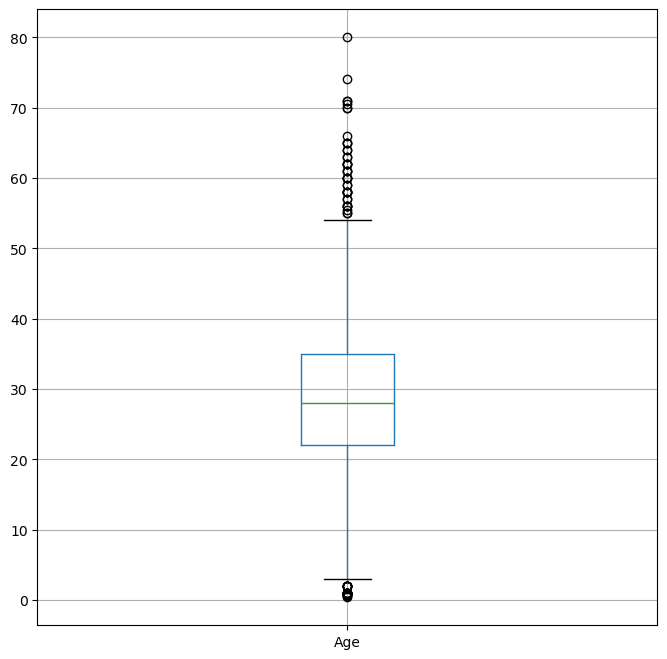

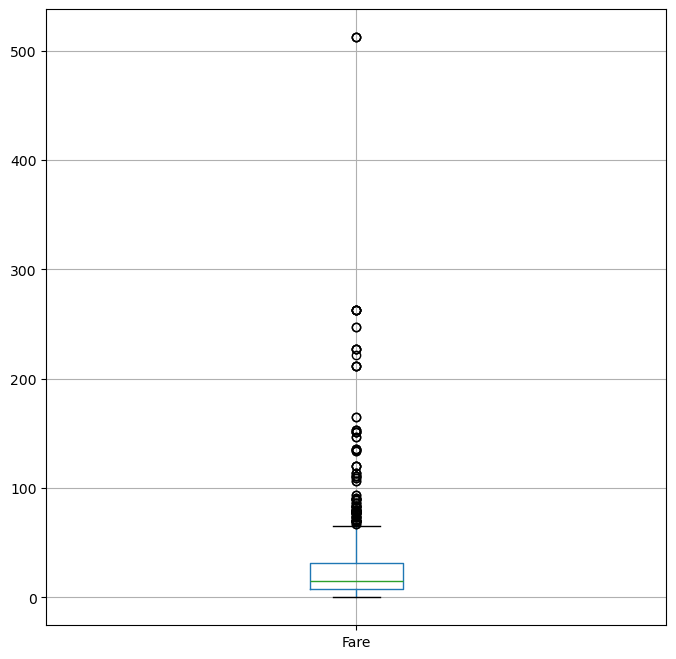

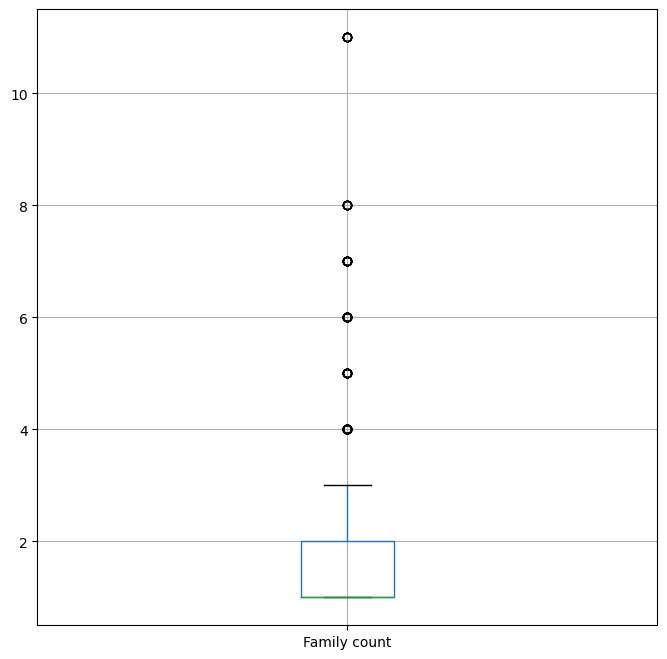

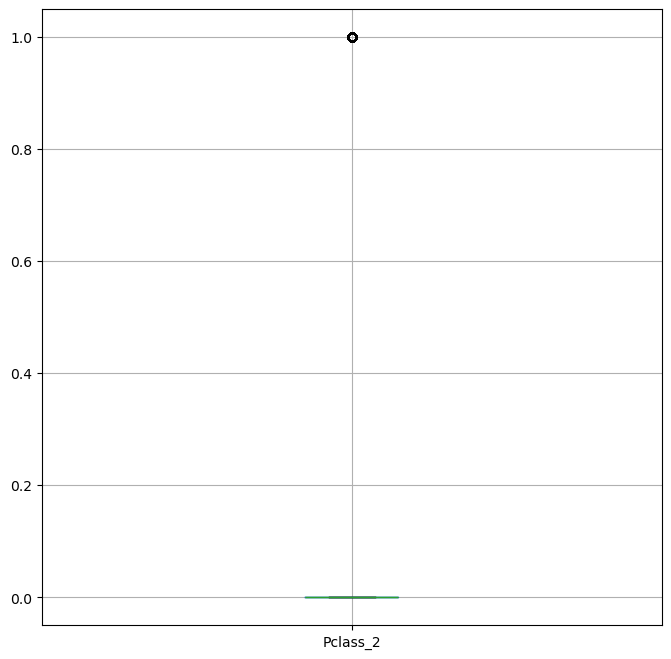

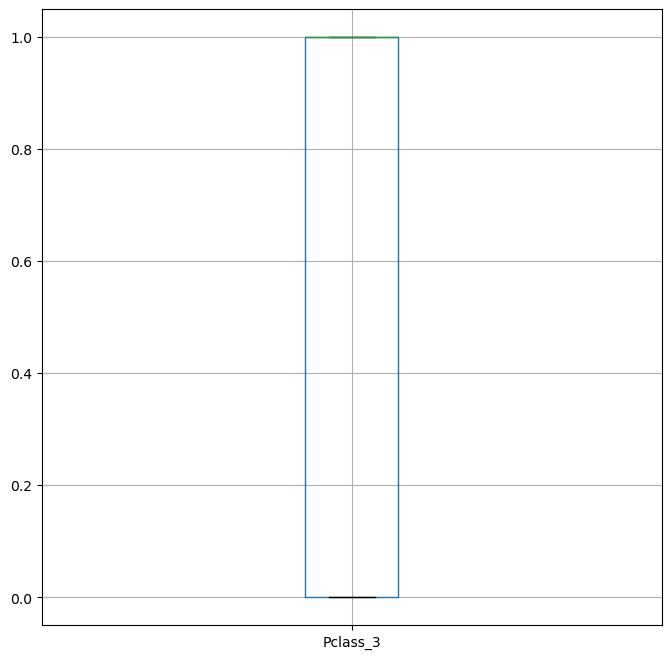

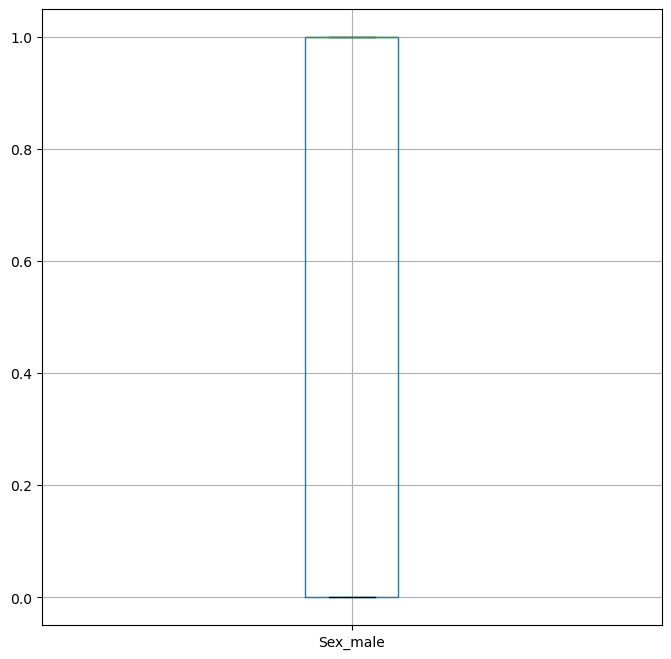

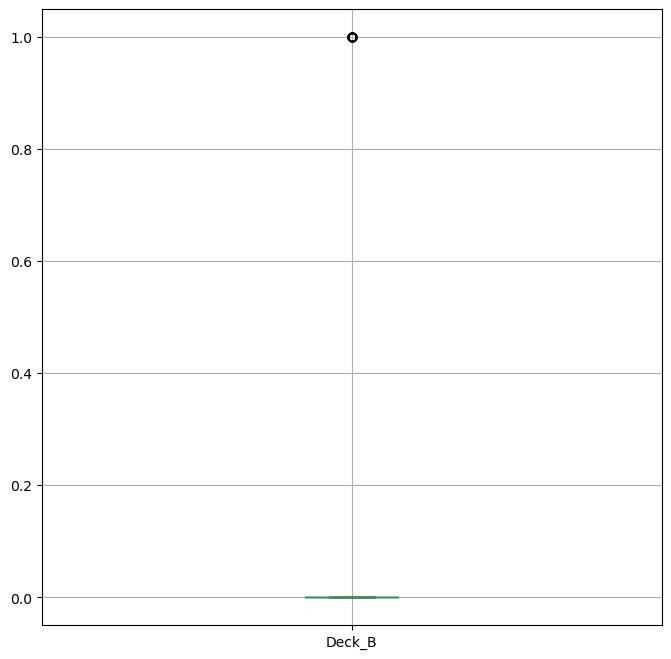

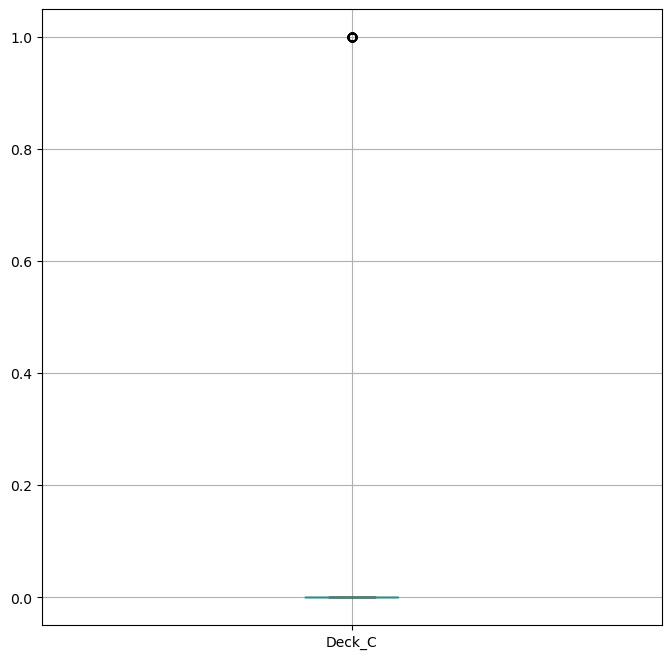

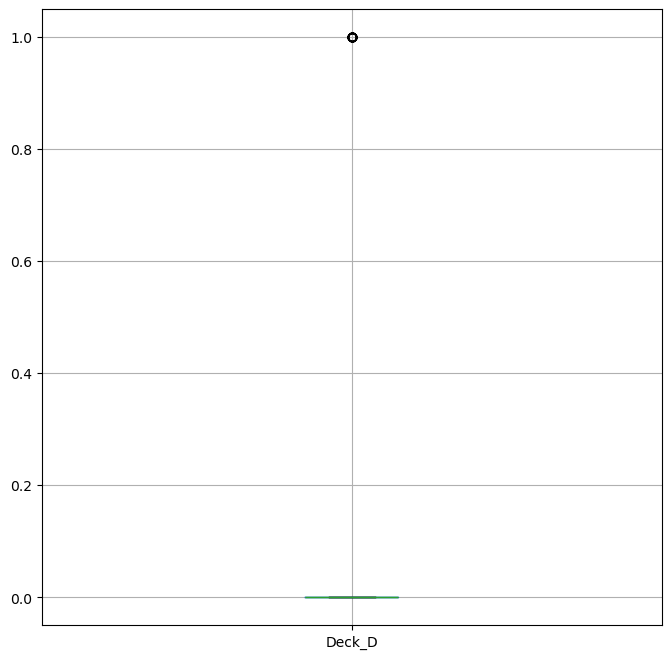

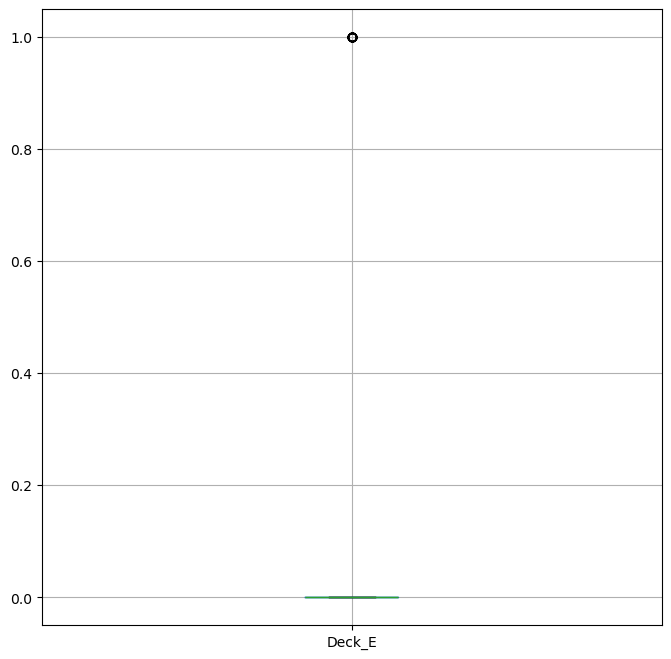

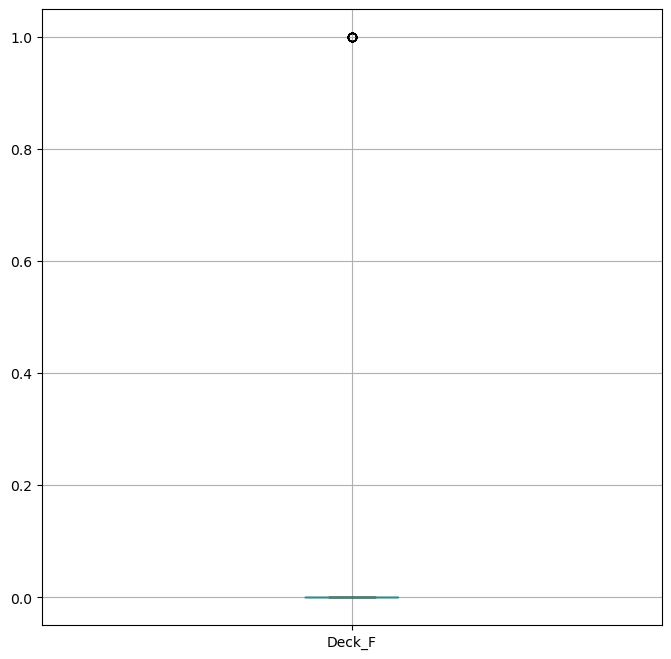

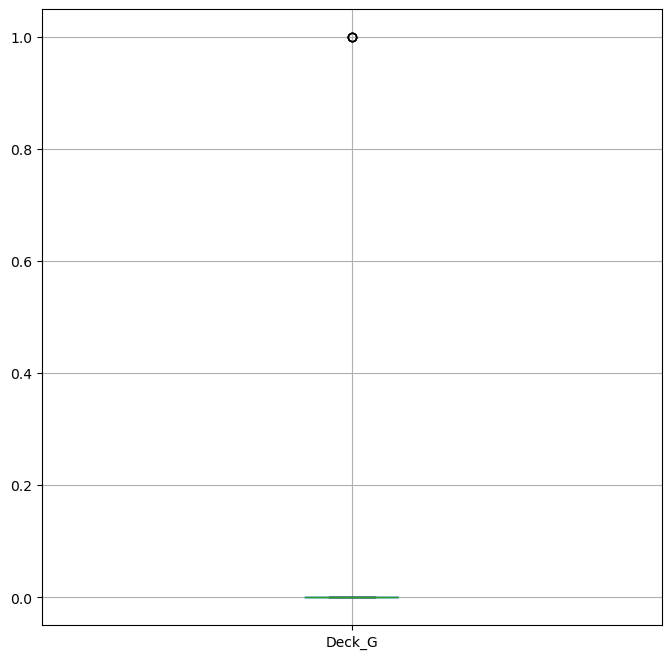

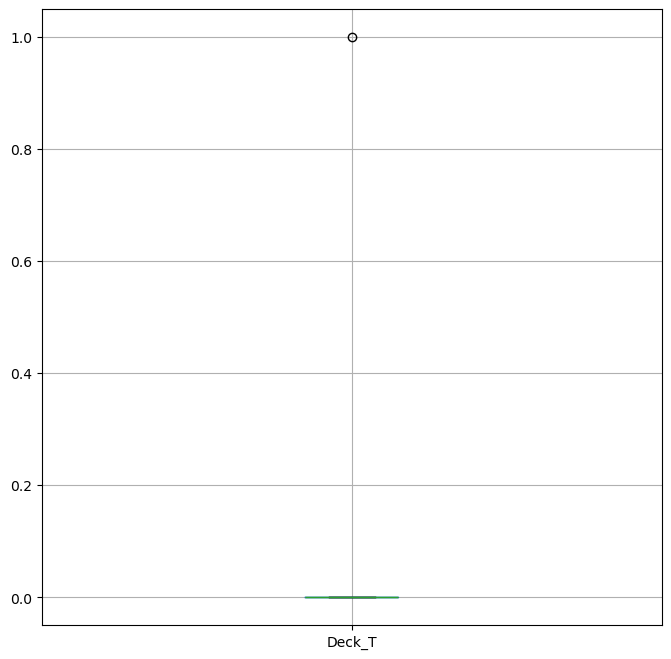

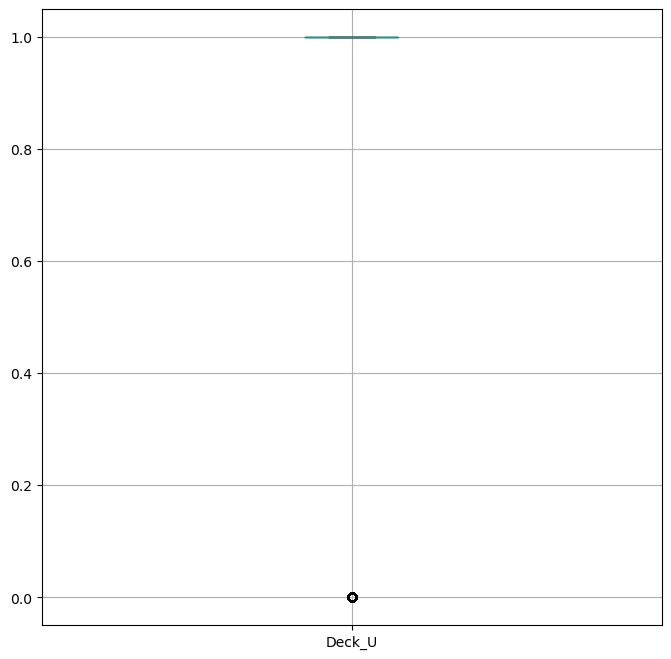

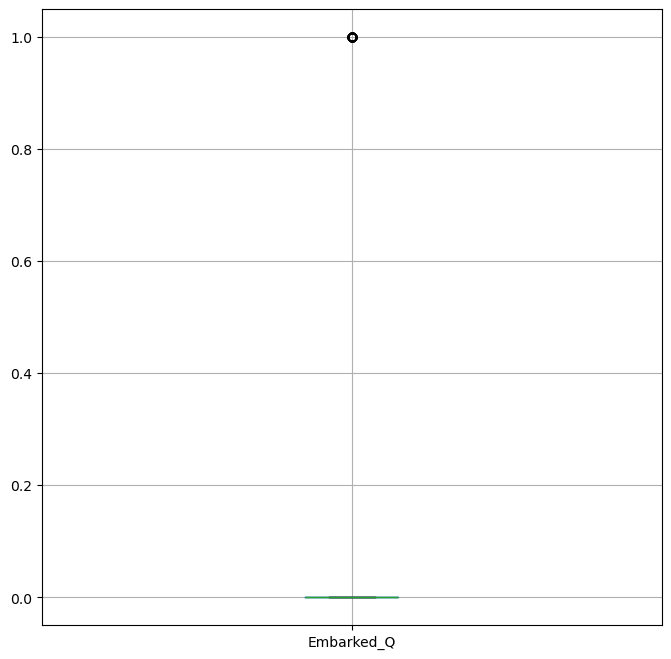

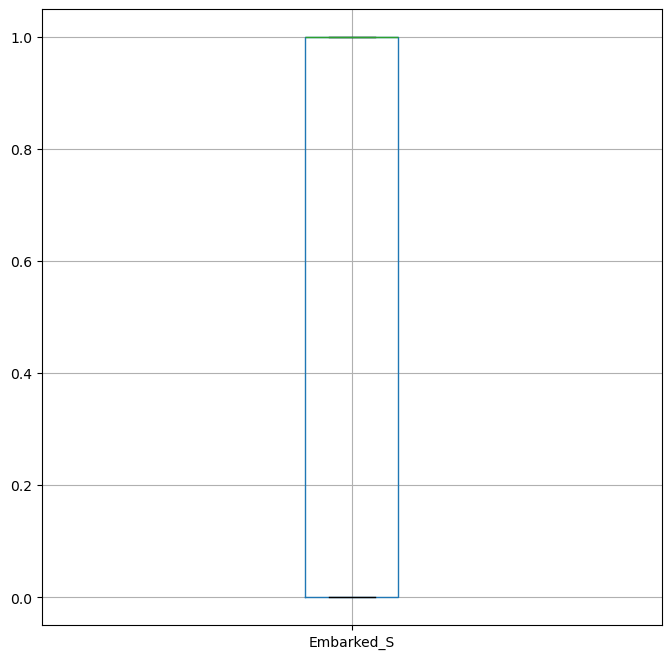

In [15]:
n=len(data_train_1.columns)
for i in range (0,n):
    plt.figure(figsize=[8,8])
    data_train_1.boxplot(column=[data_train_1.columns[i]])
    plt.show()

In [16]:
def remove_outlier(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_range=Q1-(1.5*IQR)
    upper_range=Q3+(1.5*IQR)
    return lower_range,upper_range

In [17]:
print(data_train_1.shape)
lr_age,ur_age=remove_outlier(data_train_1['Age'])
data_train_1['Age']=np.where(data_train_1['Age']>ur_age,ur_age,data_train_1['Age'])
data_train_1['Age']=np.where(data_train_1['Age']<lr_age,lr_age,data_train_1['Age'])

lrfare,urfare=remove_outlier(data_train_1['Fare'])
data_train_1['Fare']=np.where(data_train_1['Fare']>urfare,urfare,data_train_1['Fare'])
data_train_1['Fare']=np.where(data_train_1['Fare']<lrfare,lrfare,data_train_1['Fare'])

lrfamilycount,urfamilycount=remove_outlier(data_train_1['Family count'])
data_train_1['Family count']=np.where(data_train_1['Family count']>urfamilycount,urfamilycount,data_train_1['Family count'])
data_train_1['Family count']=np.where(data_train_1['Family count']<lrfamilycount,lrfamilycount,data_train_1['Family count'])

print(data_train_1.shape)

(891, 17)
(891, 17)


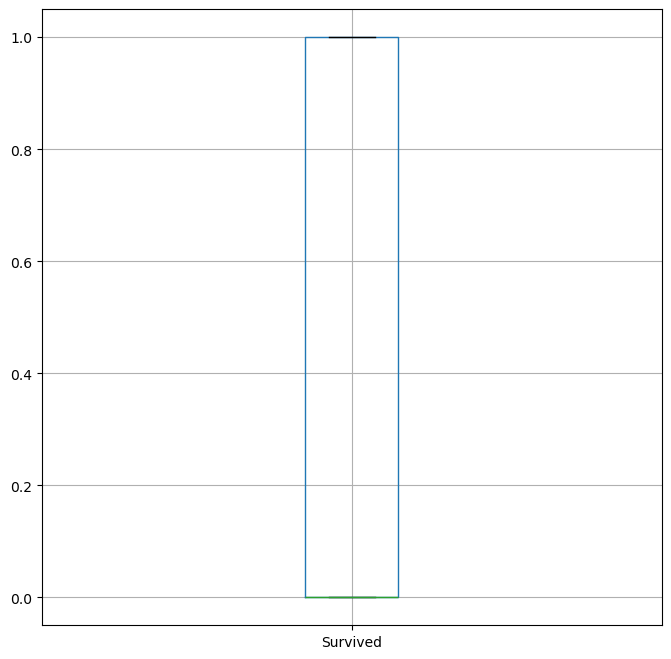

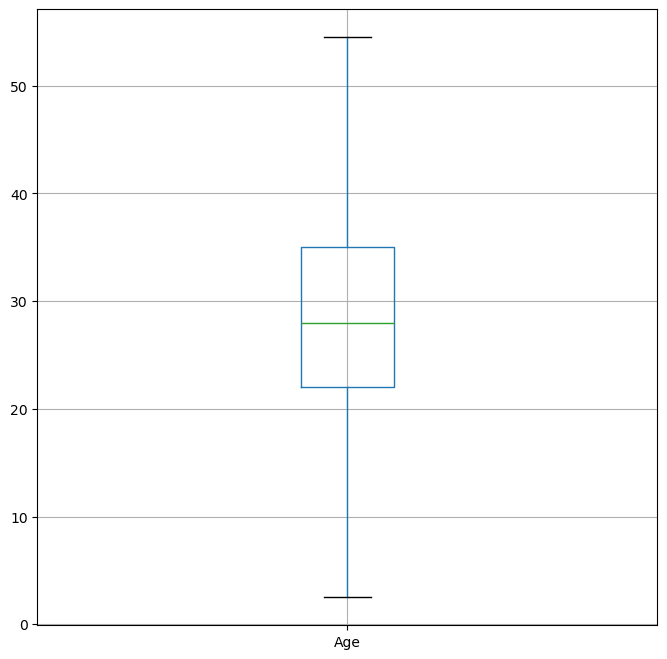

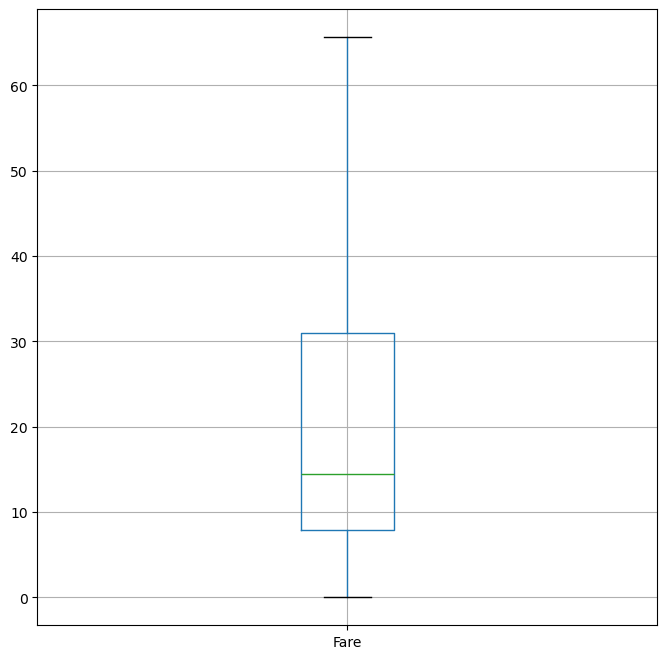

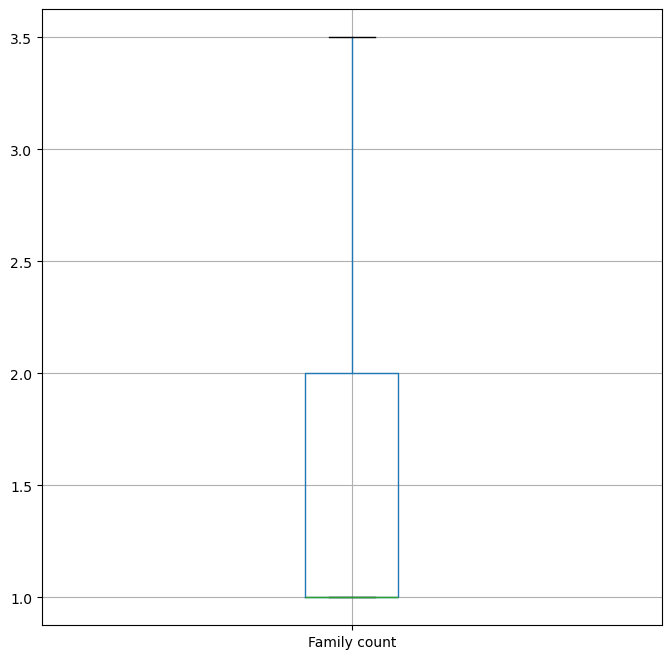

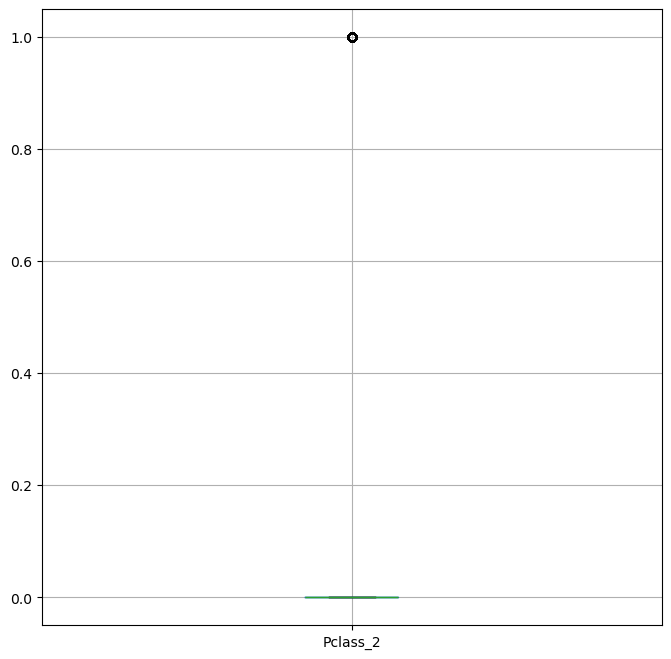

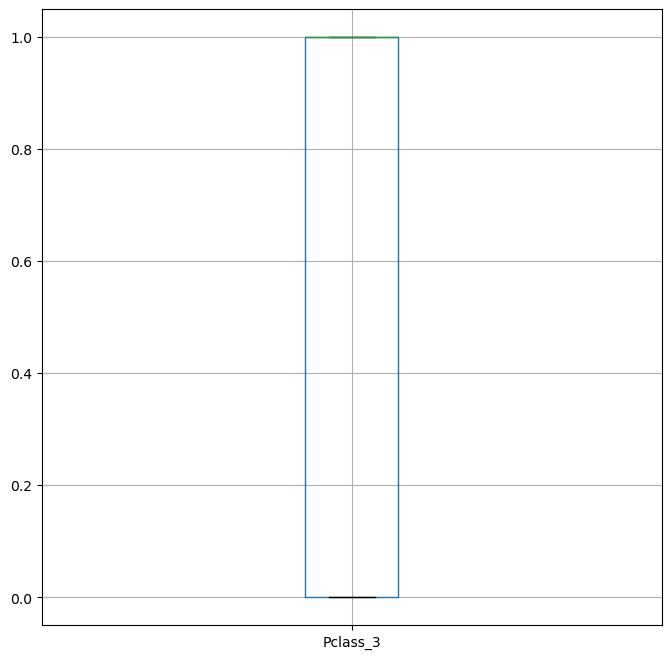

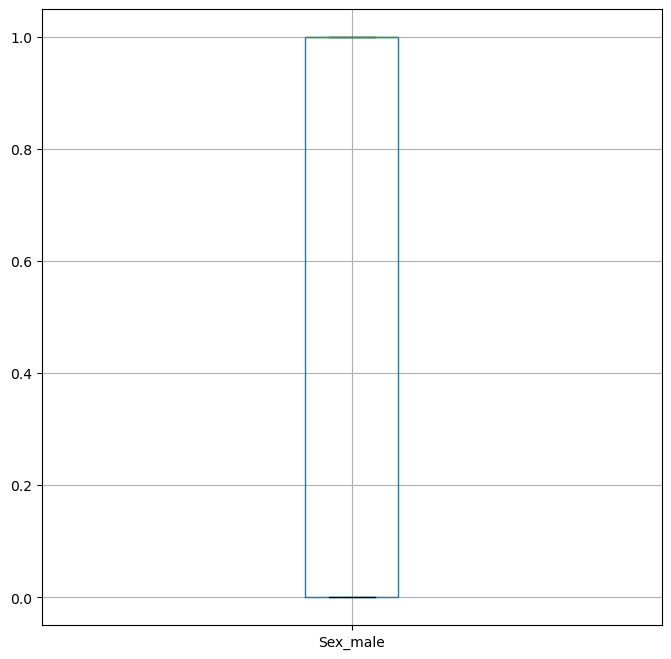

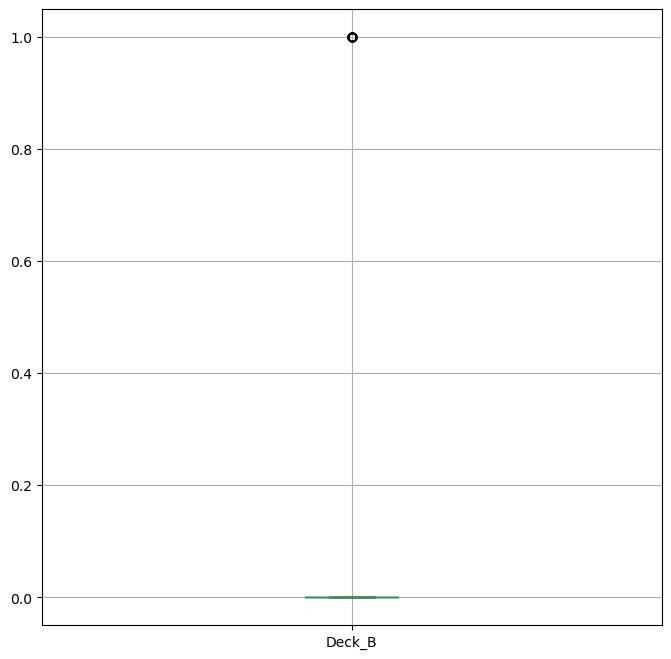

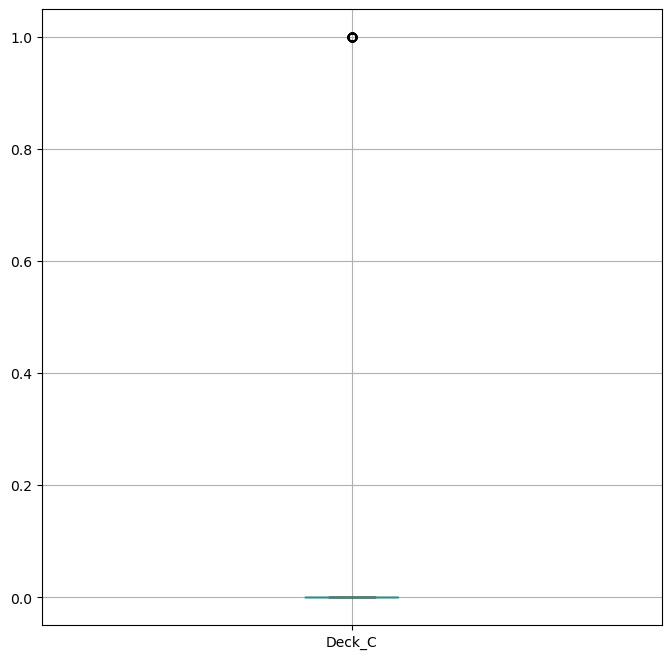

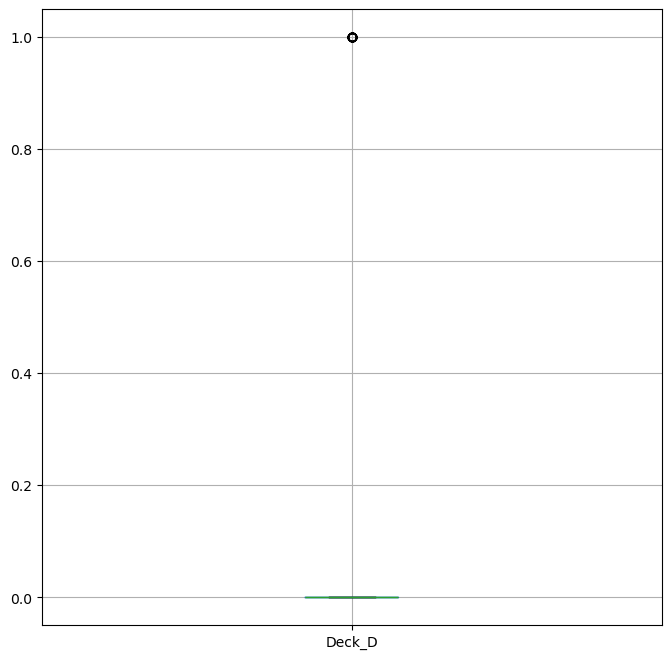

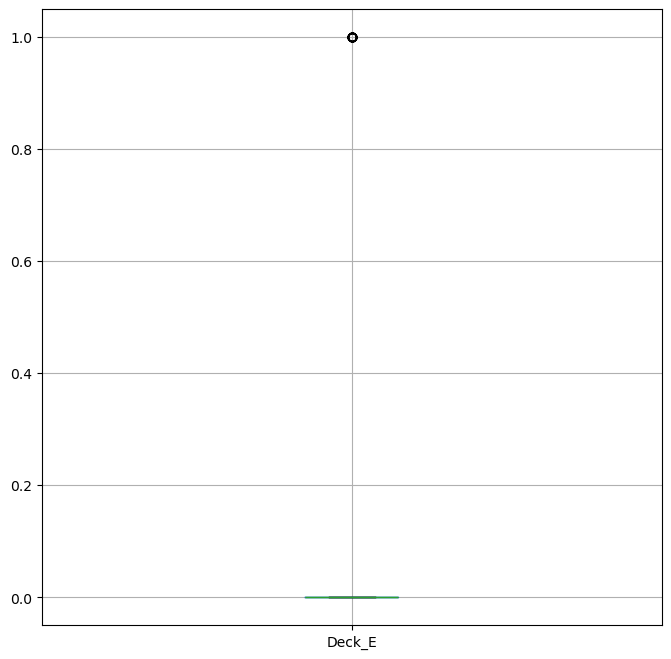

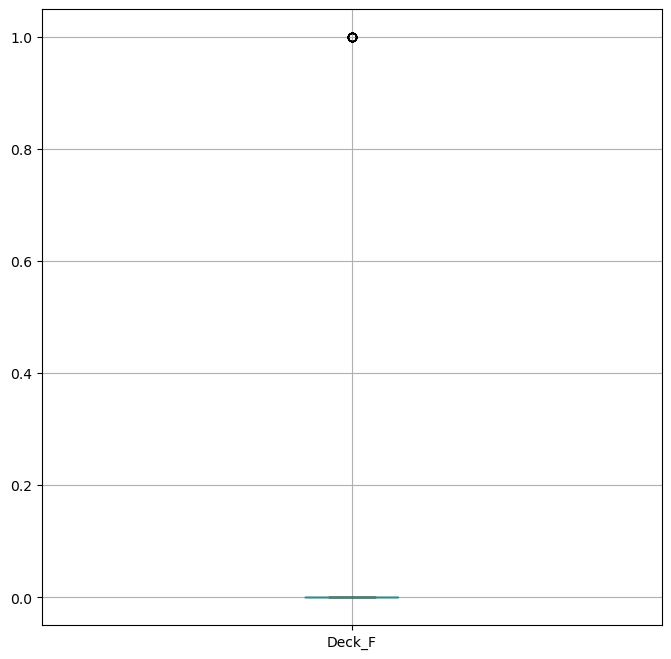

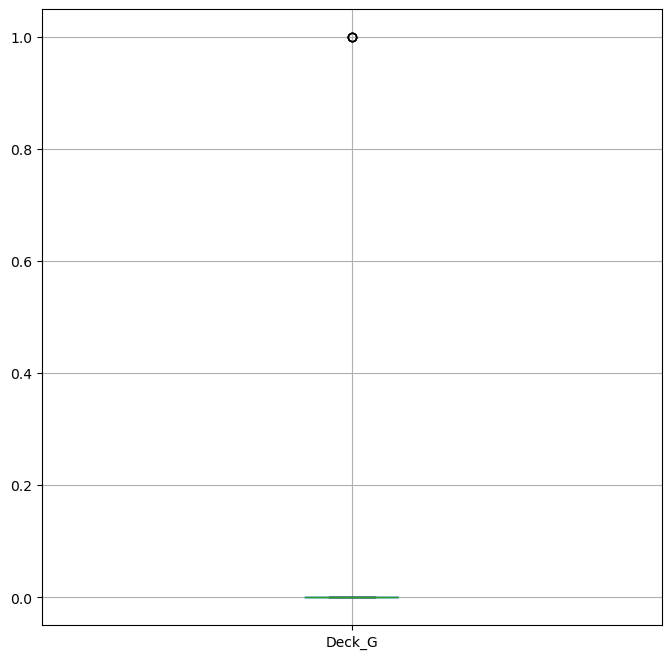

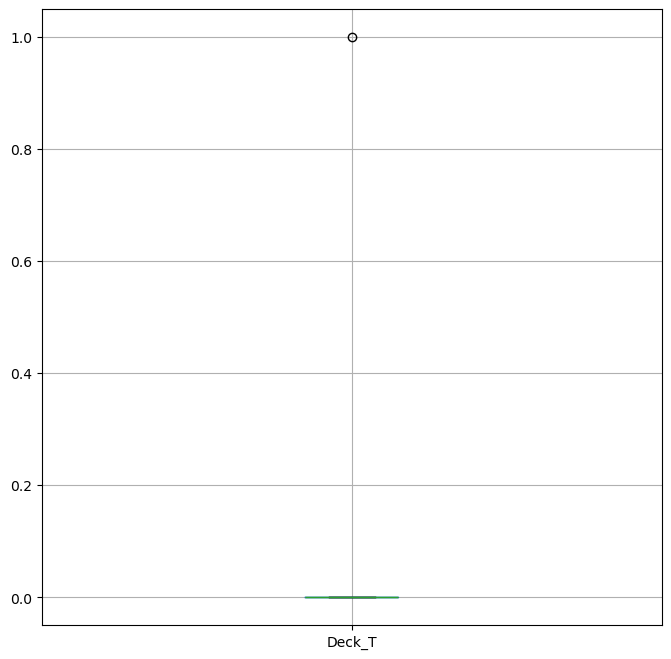

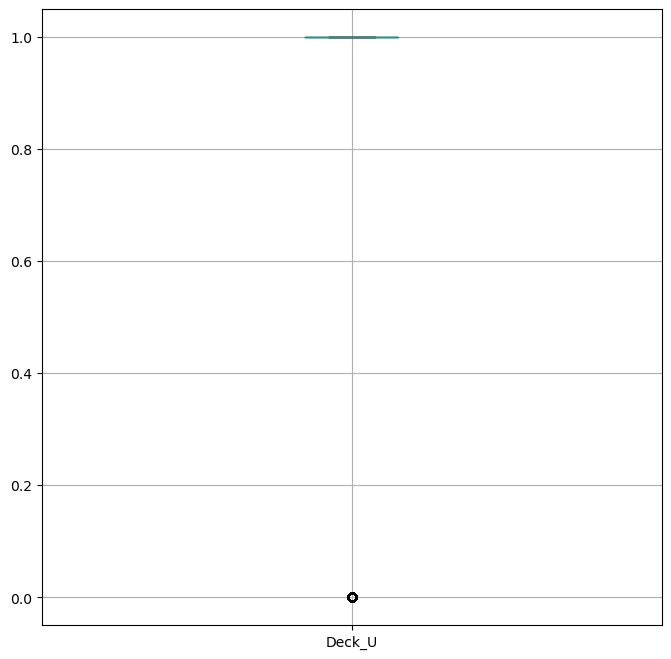

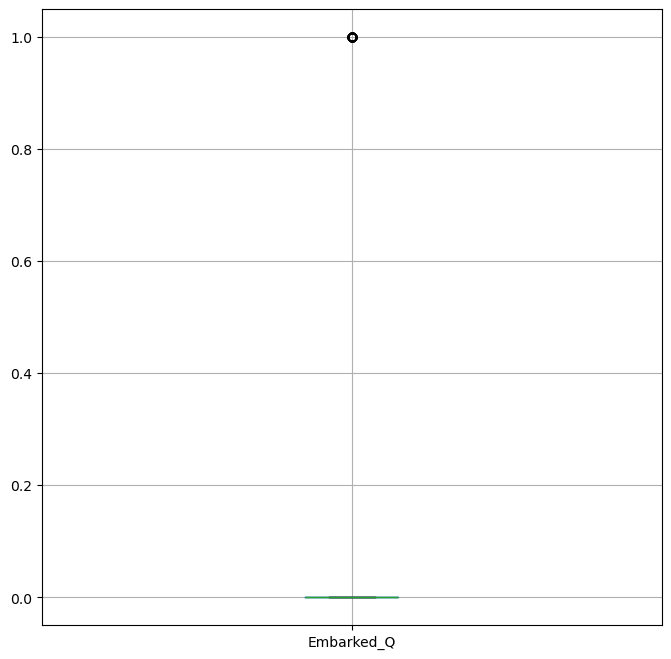

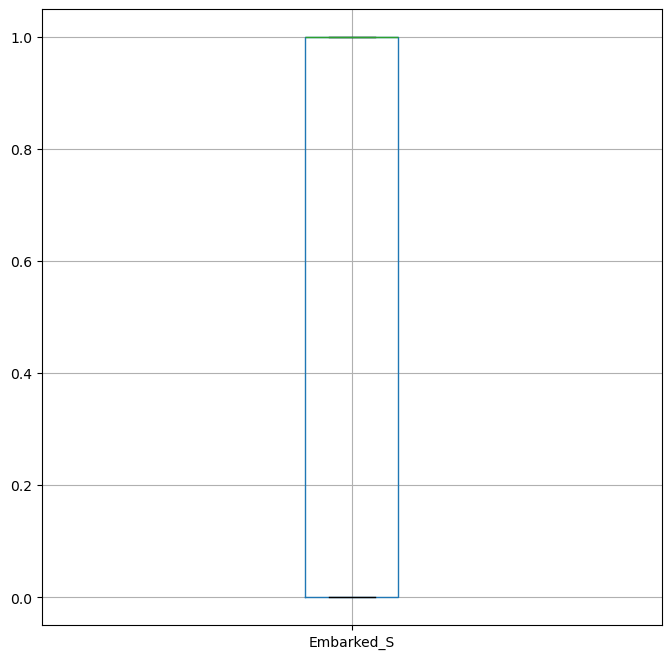

In [18]:
n=len(data_train_1.columns)
for i in range (0,n):
    plt.figure(figsize=[8,8])
    data_train_1.boxplot(column=[data_train_1.columns[i]])
    plt.show()

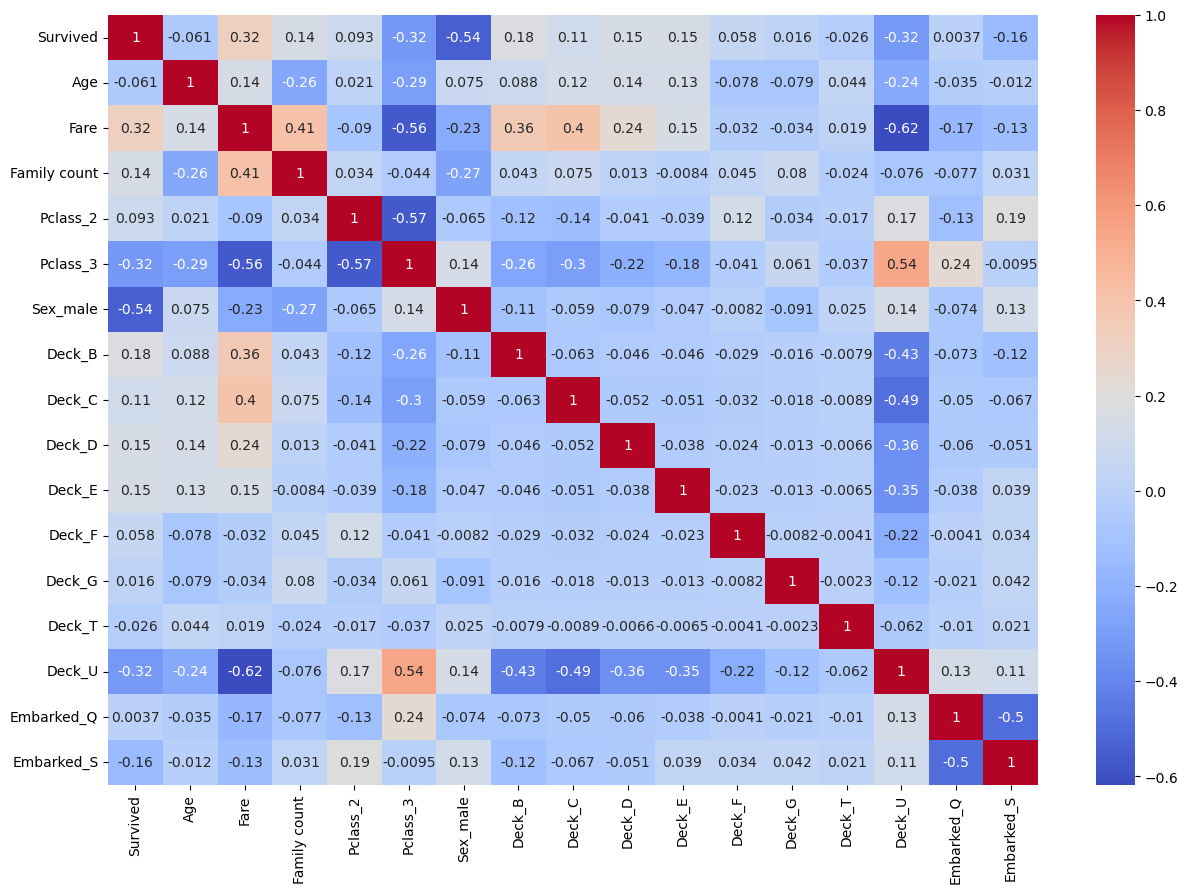

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(data_train_1.corr(),annot=True,cmap='coolwarm')
plt.show()

**SAME EDA PROCESSES FOR TEST CSV AS WELL**

In [20]:
data_test=pd.read_csv(r"C:\Users\HP\Downloads\XGBM & LGBM\XGBM & LGBM\Titanic_test.csv")
data_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [21]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [22]:
data_test_1=data_test.drop(["PassengerId","Name","Ticket"],axis=1)
data_test_1

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,34.5,0,0,7.8292,NaN,Q
1,3,female,47.0,1,0,7.0000,NaN,S
2,2,male,62.0,0,0,9.6875,NaN,Q
3,3,male,27.0,0,0,8.6625,NaN,S
4,3,female,22.0,1,1,12.2875,NaN,S
...,...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,NaN,S
414,1,female,39.0,0,0,108.9000,C105,C
415,3,male,38.5,0,0,7.2500,NaN,S
416,3,male,NaN,0,0,8.0500,NaN,S


In [23]:
print(data_test_1.isnull().sum())
median_age = data_test_1['Age'].median()
median_fare=data_test_1["Fare"].median()
data_test_1["Age"]=data_test_1["Age"].fillna(median_age)
data_test_1["Fare"]=data_test_1["Fare"].fillna(median_fare)
data_test_1.isnull().sum()

Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Fare          1
Cabin       327
Embarked      0
dtype: int64


Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       327
Embarked      0
dtype: int64

In [24]:
data_test_1['Deck'] = data_test_1['Cabin'].str[0]
data_test_1['Deck']=data_test_1['Deck'].fillna('U')
data_test_1['Deck']

0      U
1      U
2      U
3      U
4      U
      ..
413    U
414    C
415    U
416    U
417    U
Name: Deck, Length: 418, dtype: object

In [25]:
data_test_1['Family count']=data_test_1["SibSp"]+data_test_1["Parch"]+1
data_test_1['Family count']

0      1
1      2
2      1
3      1
4      3
      ..
413    1
414    1
415    1
416    1
417    3
Name: Family count, Length: 418, dtype: int64

In [26]:
data_test_1=data_test_1.drop(["Cabin","SibSp","Parch"],axis=1)
data_test_1

,Pclass,Sex,Age,Fare,Embarked,Deck,Family count
0,3,male,34.5,7.8292,Q,U,1
1,3,female,47.0,7.0000,S,U,2
2,2,male,62.0,9.6875,Q,U,1
3,3,male,27.0,8.6625,S,U,1
4,3,female,22.0,12.2875,S,U,3
...,...,...,...,...,...,...,...
413,3,male,27.0,8.0500,S,U,1
414,1,female,39.0,108.9000,C,C,1
415,3,male,38.5,7.2500,S,U,1
416,3,male,27.0,8.0500,S,U,1


In [27]:
data_test_1=pd.get_dummies(data_test_1, columns=["Pclass","Sex","Deck","Embarked"],drop_first=True, dtype=int)
data_test_1

,Age,Fare,Family count,Pclass_2,Pclass_3,Sex_male,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_U,Embarked_Q,Embarked_S
0,34.5,7.8292,1,0,1,1,0,0,0,0,0,0,1,1,0
1,47.0,7.0000,2,0,1,0,0,0,0,0,0,0,1,0,1
2,62.0,9.6875,1,1,0,1,0,0,0,0,0,0,1,1,0
3,27.0,8.6625,1,0,1,1,0,0,0,0,0,0,1,0,1
4,22.0,12.2875,3,0,1,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,27.0,8.0500,1,0,1,1,0,0,0,0,0,0,1,0,1
414,39.0,108.9000,1,0,0,0,0,1,0,0,0,0,0,0,0
415,38.5,7.2500,1,0,1,1,0,0,0,0,0,0,1,0,1
416,27.0,8.0500,1,0,1,1,0,0,0,0,0,0,1,0,1


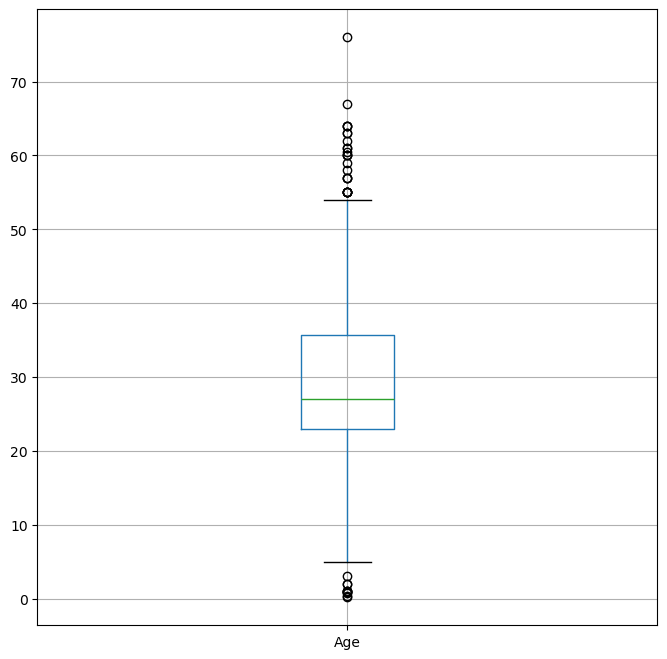

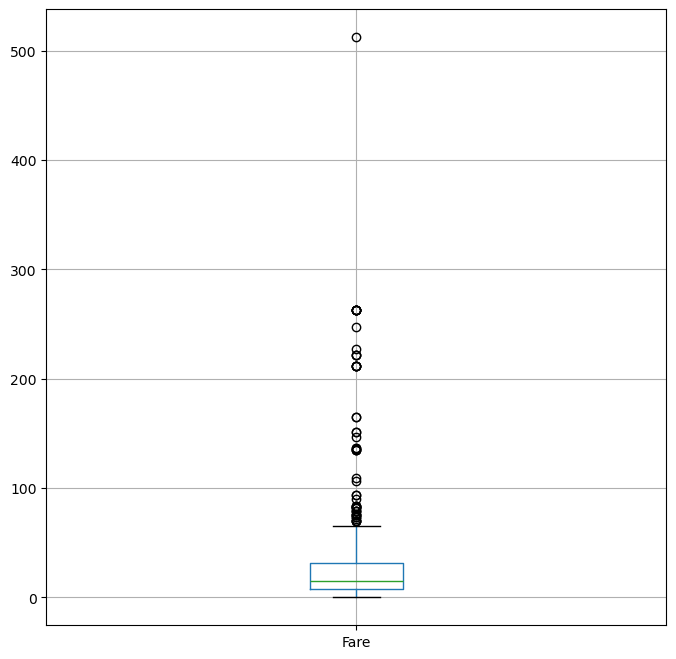

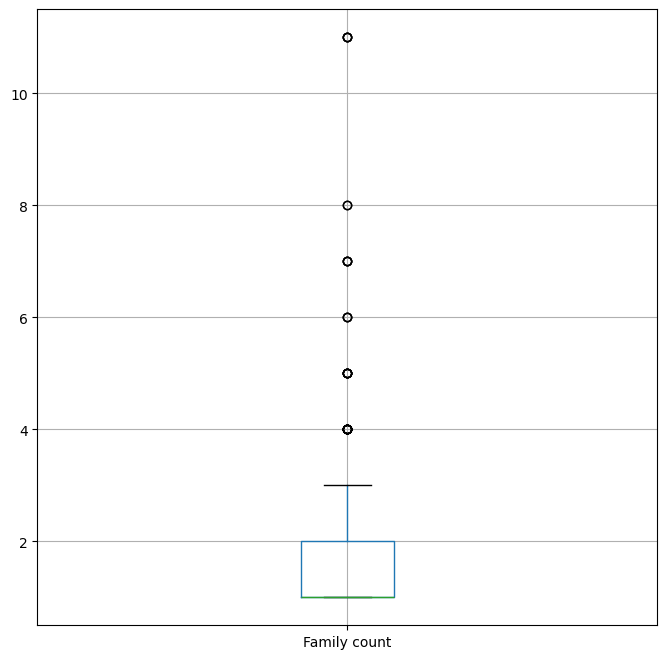

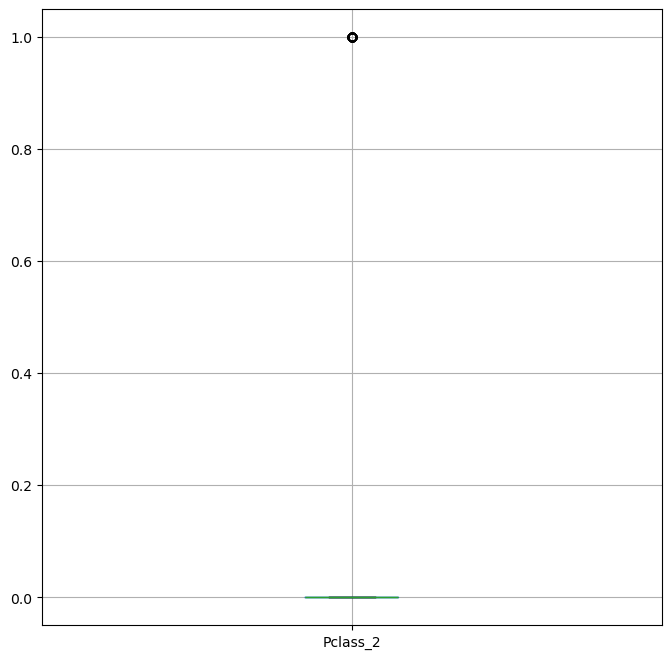

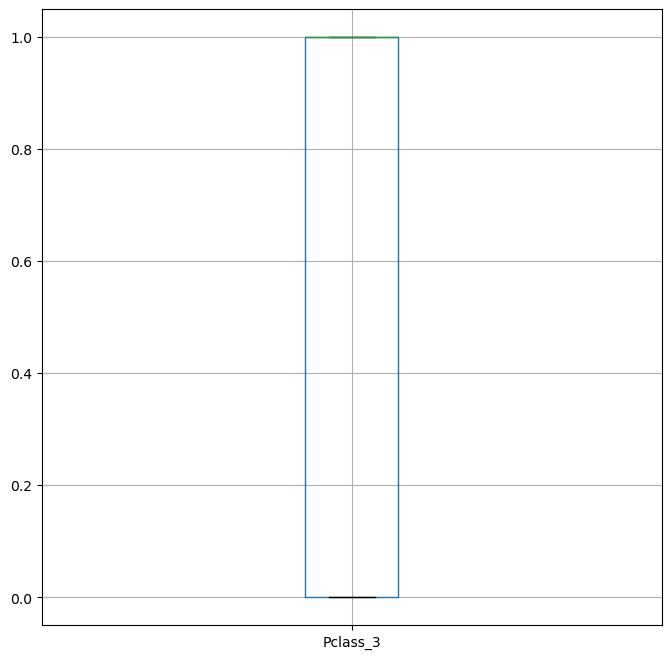

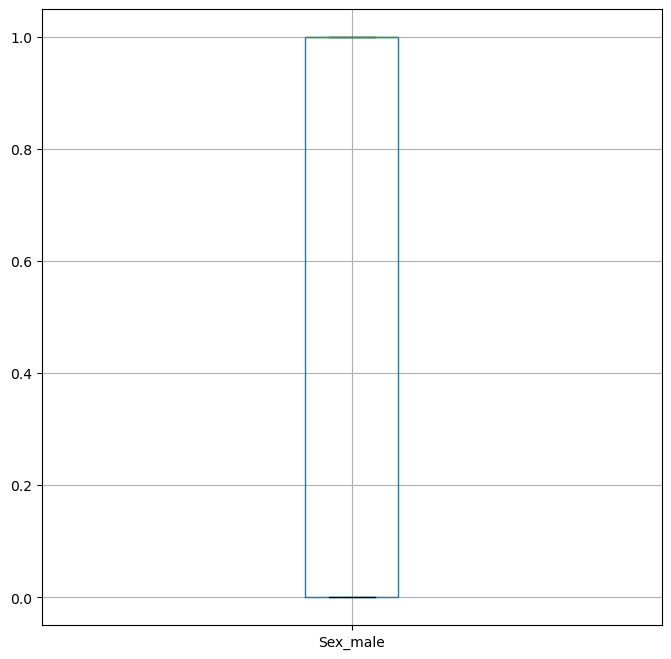

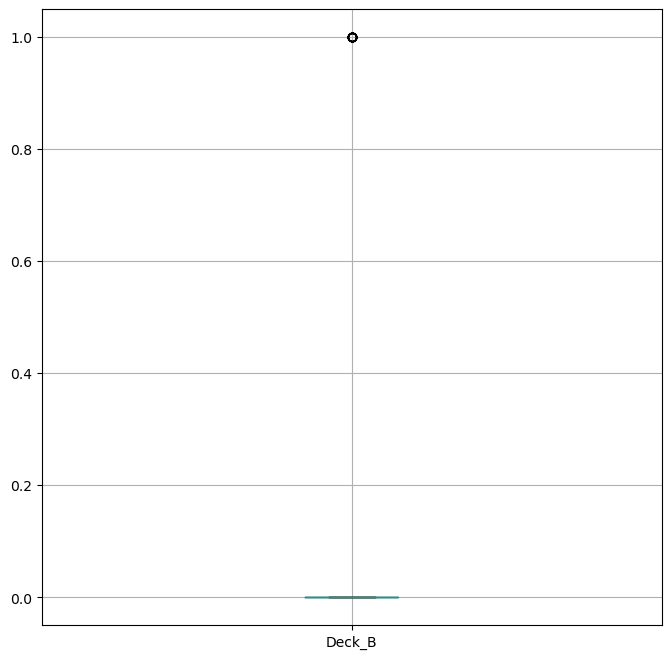

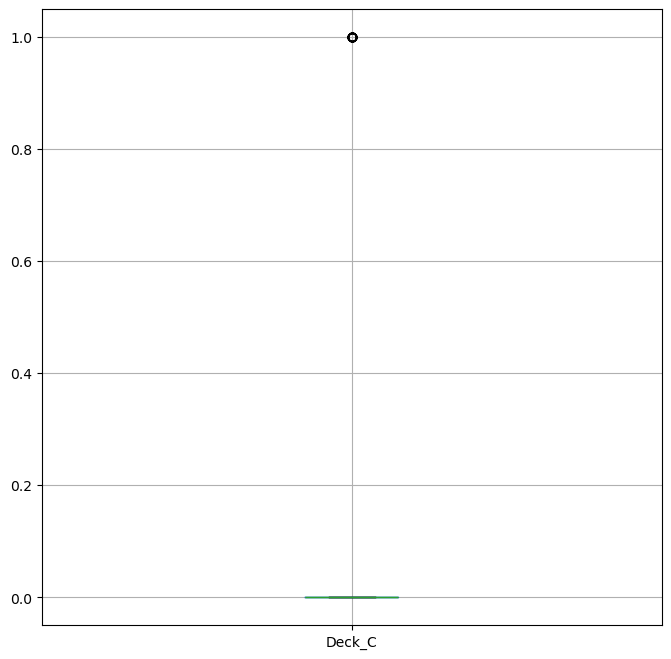

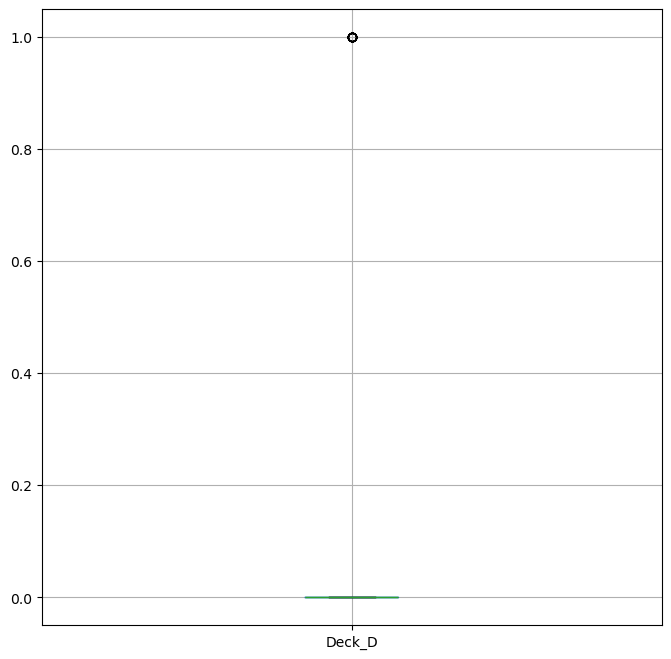

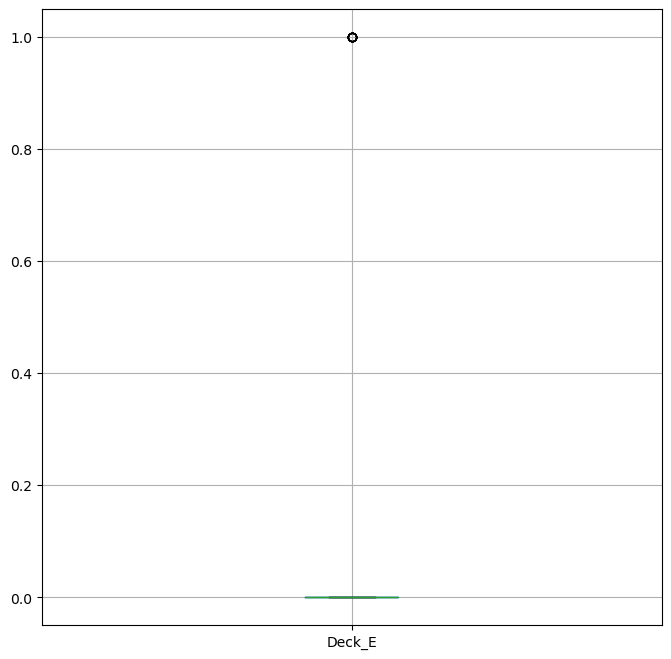

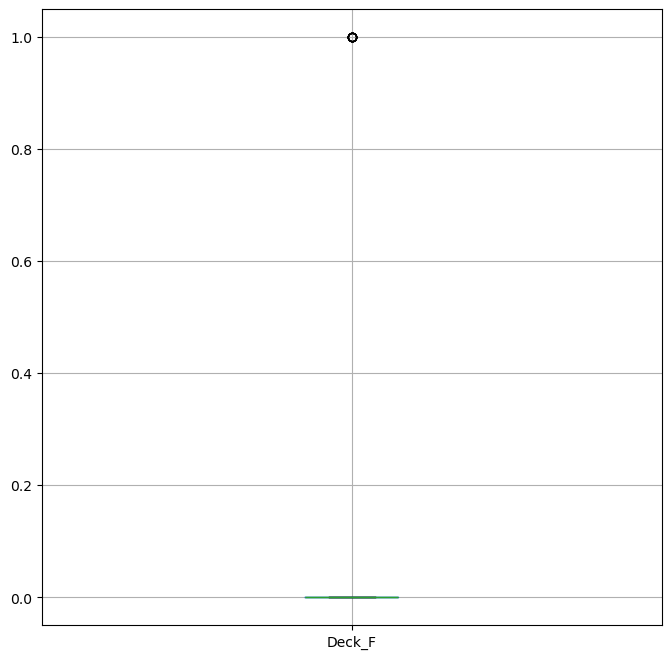

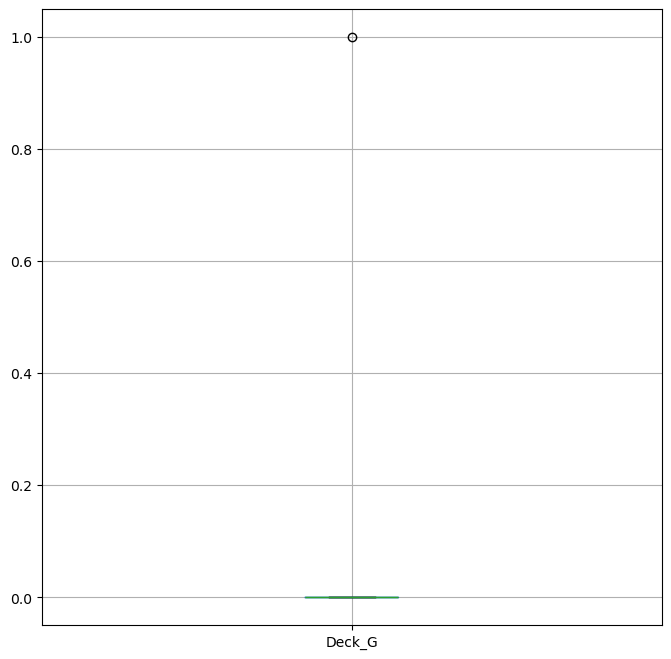

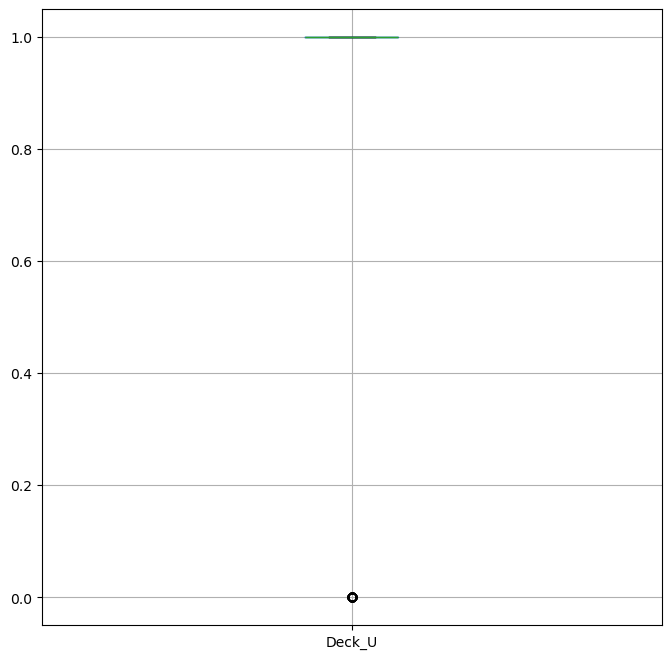

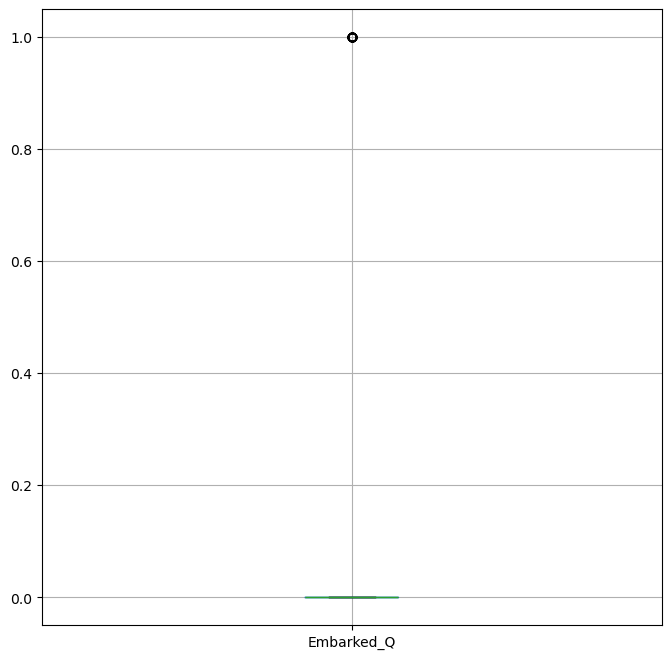

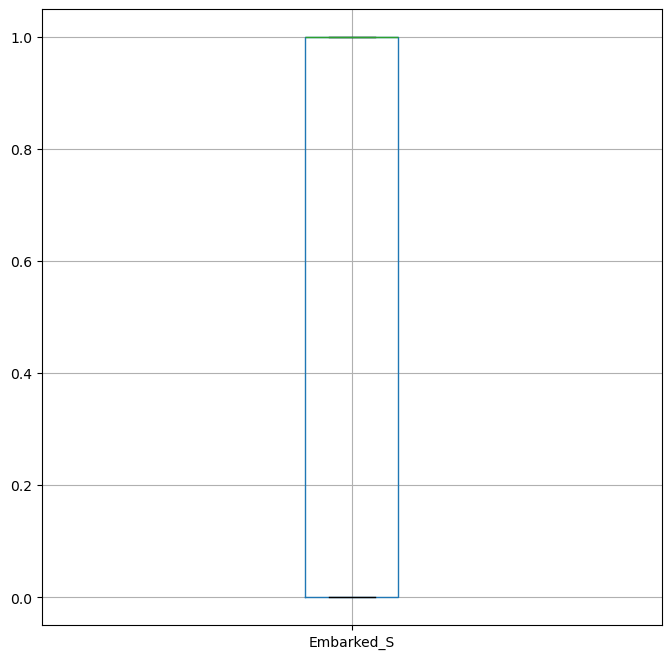

In [28]:
n=len(data_test_1.columns)
for i in range (0,n):
    plt.figure(figsize=[8,8])
    data_test_1.boxplot(column=[data_test_1.columns[i]])
    plt.show()

In [29]:
print(data_test_1.shape)
lr_age_1,ur_age_1=remove_outlier(data_test_1['Age'])
data_test_1['Age']=np.where(data_test_1['Age']>ur_age_1,ur_age_1,data_test_1['Age'])
data_test_1['Age']=np.where(data_test_1['Age']<lr_age_1,lr_age_1,data_test_1['Age'])

lrfare1,urfare1=remove_outlier(data_test_1['Fare'])
data_test_1['Fare']=np.where(data_test_1['Fare']>urfare1,urfare1,data_test_1['Fare'])
data_test_1['Fare']=np.where(data_test_1['Fare']<lrfare1,lrfare1,data_test_1['Fare'])

lrfamilycount1,urfamilycount1=remove_outlier(data_test_1['Family count'])
data_test_1['Family count']=np.where(data_test_1['Family count']>urfamilycount1,urfamilycount1,data_test_1['Family count'])
data_test_1['Family count']=np.where(data_test_1['Family count']<lrfamilycount1,lrfamilycount1,data_test_1['Family count'])

print(data_test_1.shape)

(418, 15)
(418, 15)


In [30]:
data_test_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           418 non-null    float64
 1   Fare          418 non-null    float64
 2   Family count  418 non-null    float64
 3   Pclass_2      418 non-null    int64  
 4   Pclass_3      418 non-null    int64  
 5   Sex_male      418 non-null    int64  
 6   Deck_B        418 non-null    int64  
 7   Deck_C        418 non-null    int64  
 8   Deck_D        418 non-null    int64  
 9   Deck_E        418 non-null    int64  
 10  Deck_F        418 non-null    int64  
 11  Deck_G        418 non-null    int64  
 12  Deck_U        418 non-null    int64  
 13  Embarked_Q    418 non-null    int64  
 14  Embarked_S    418 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 49.1 KB


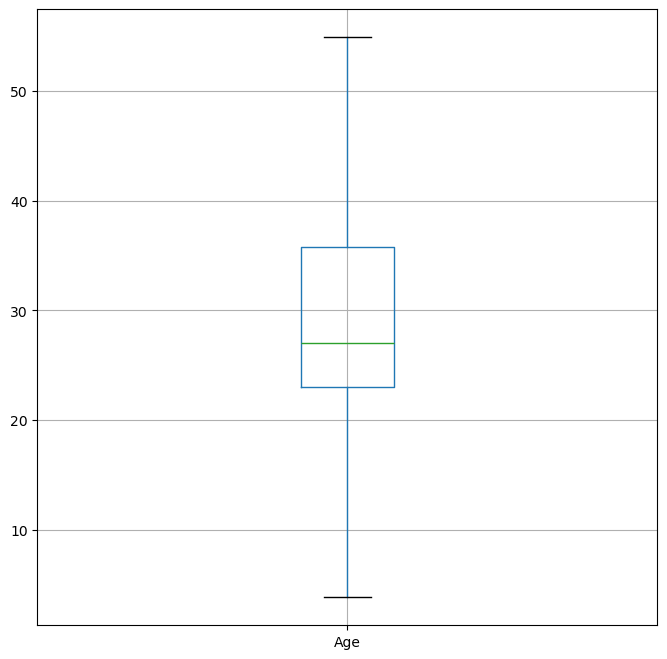

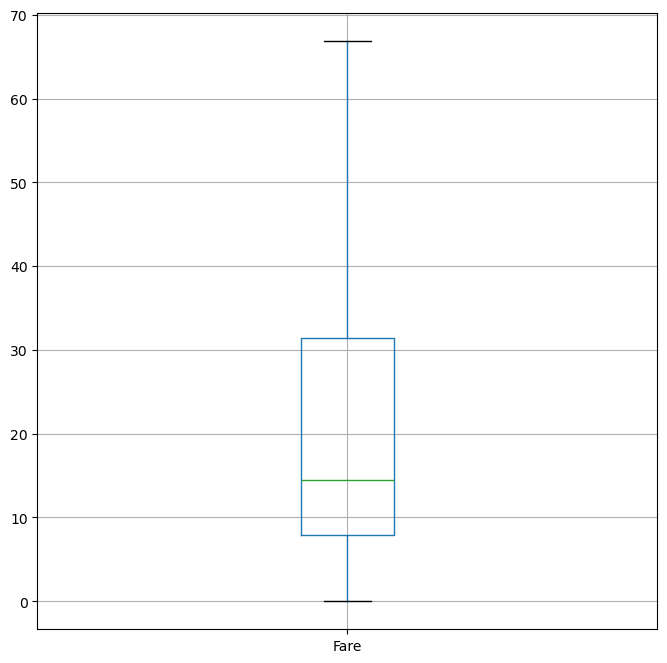

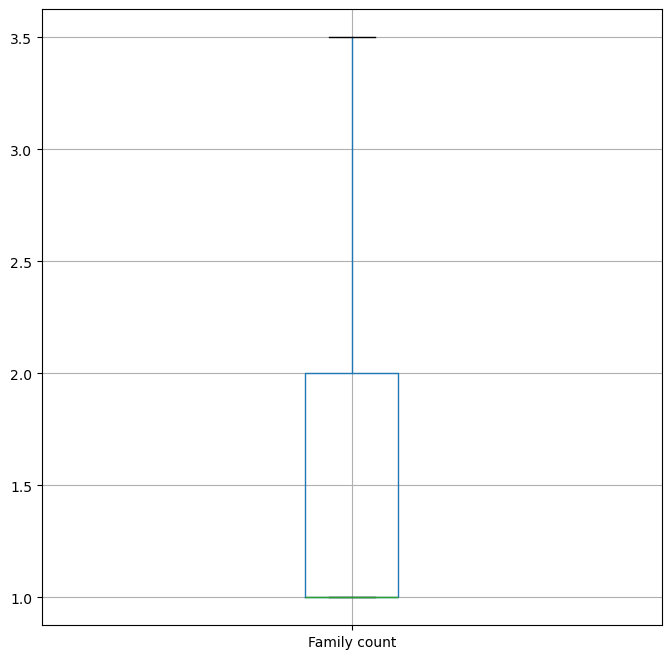

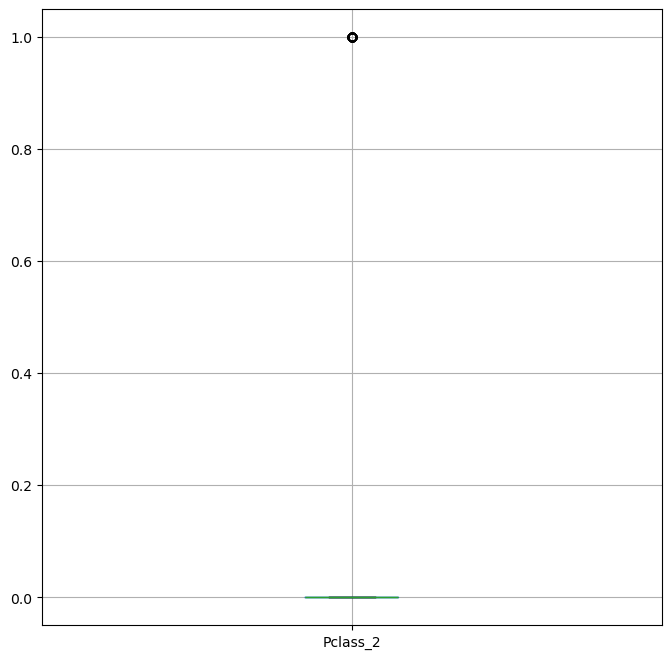

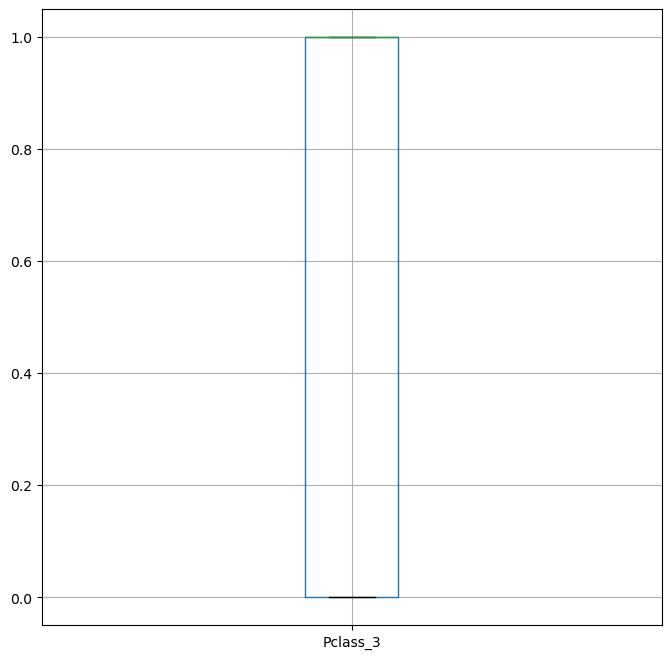

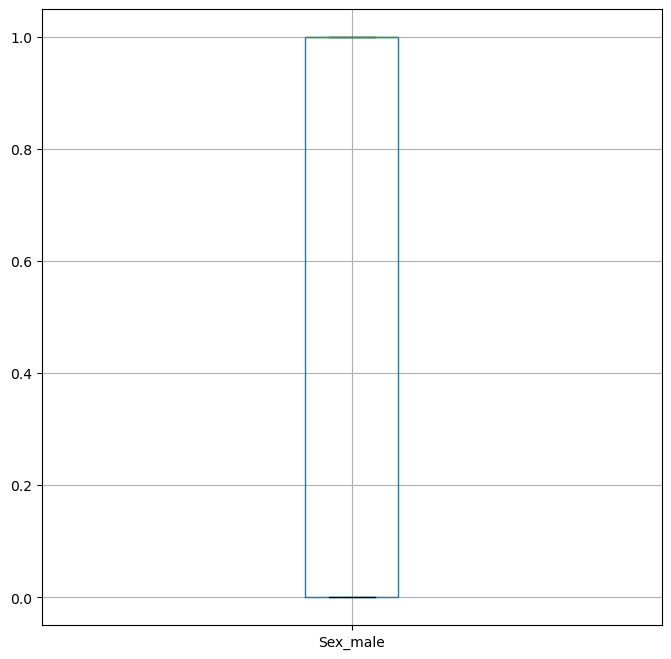

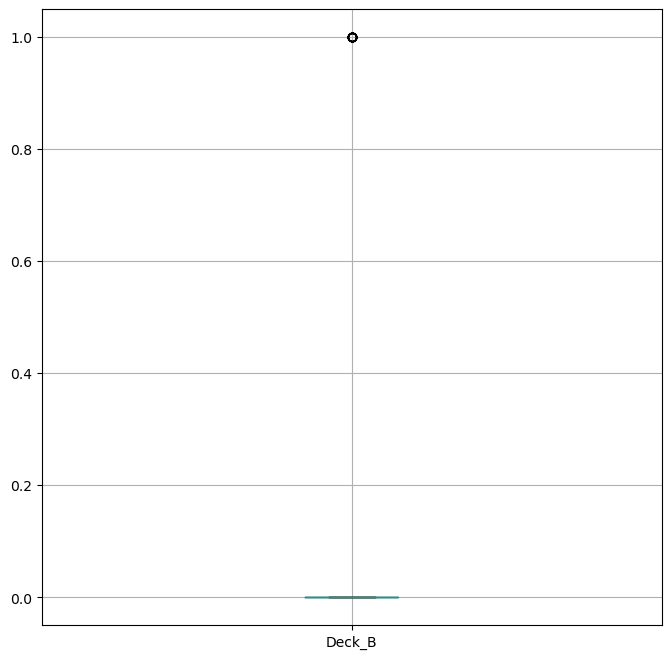

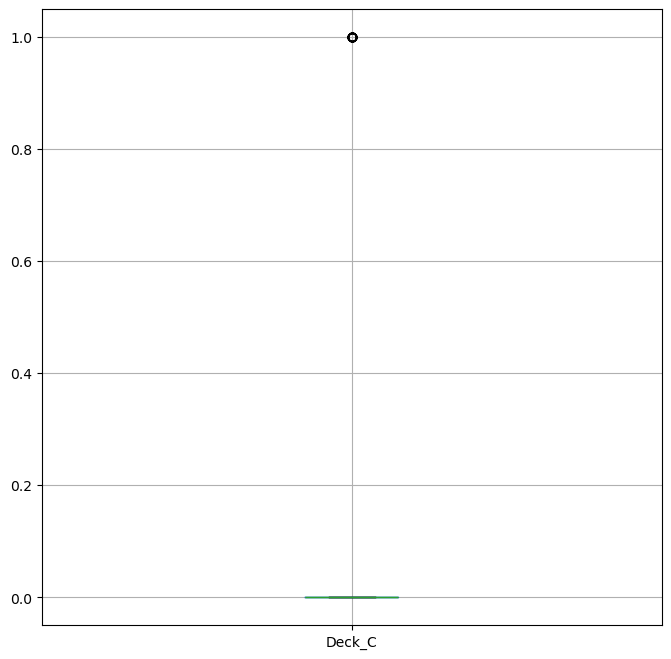

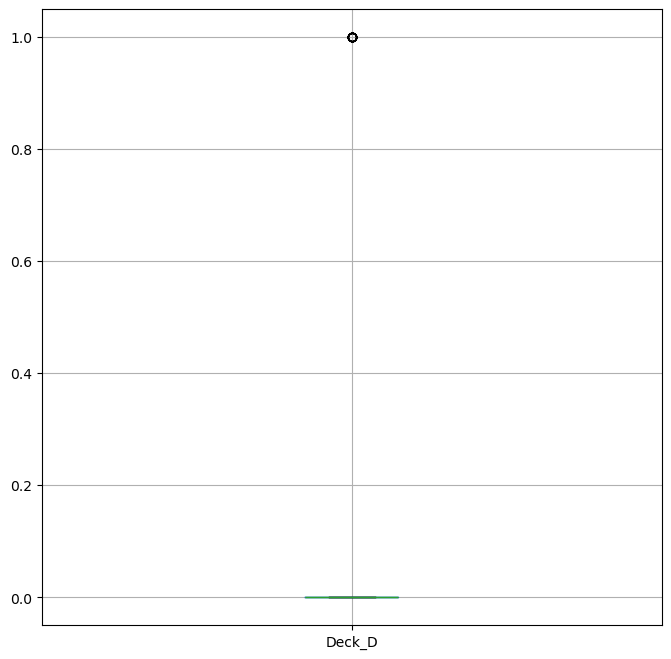

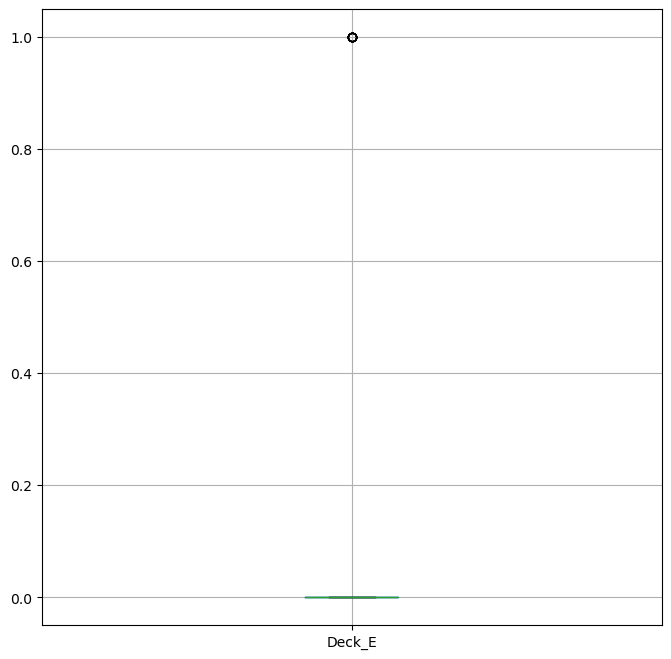

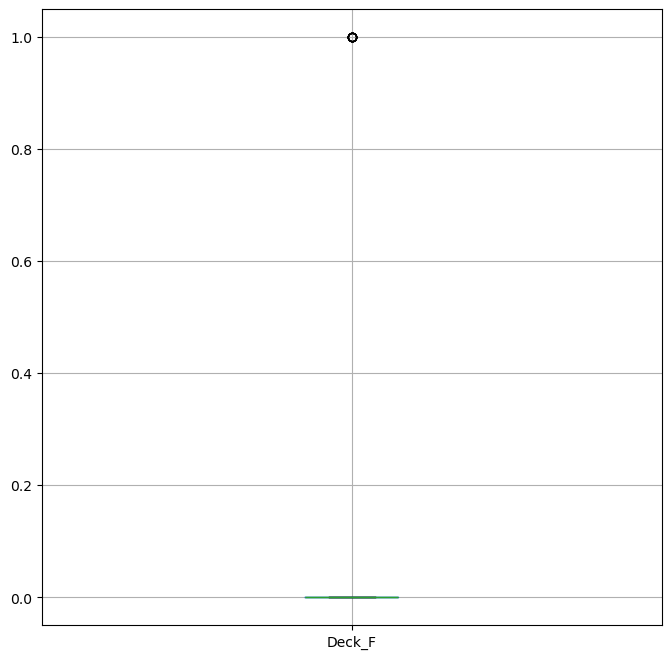

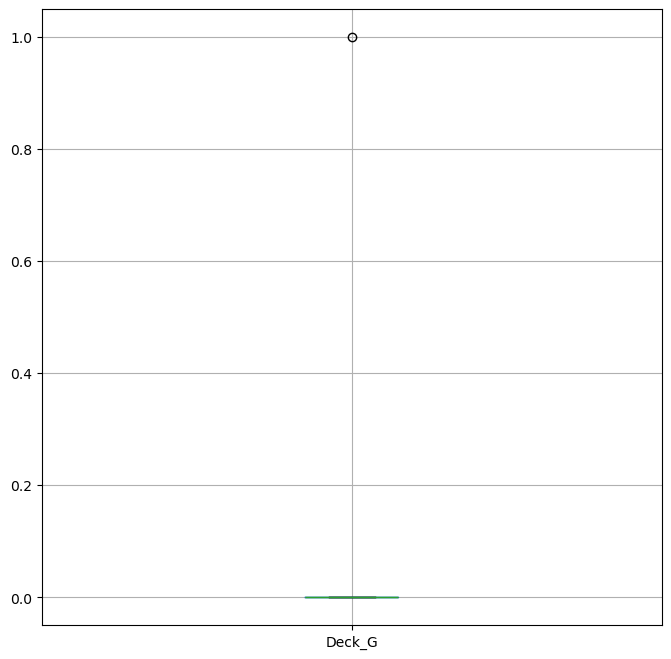

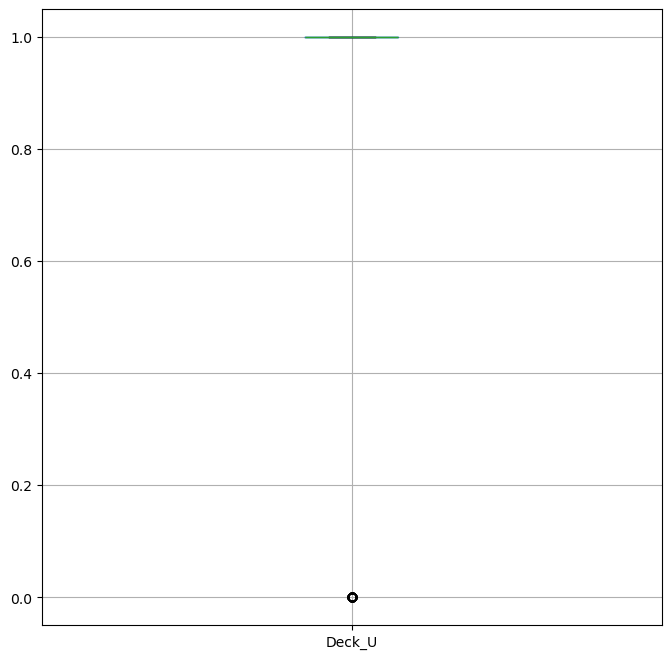

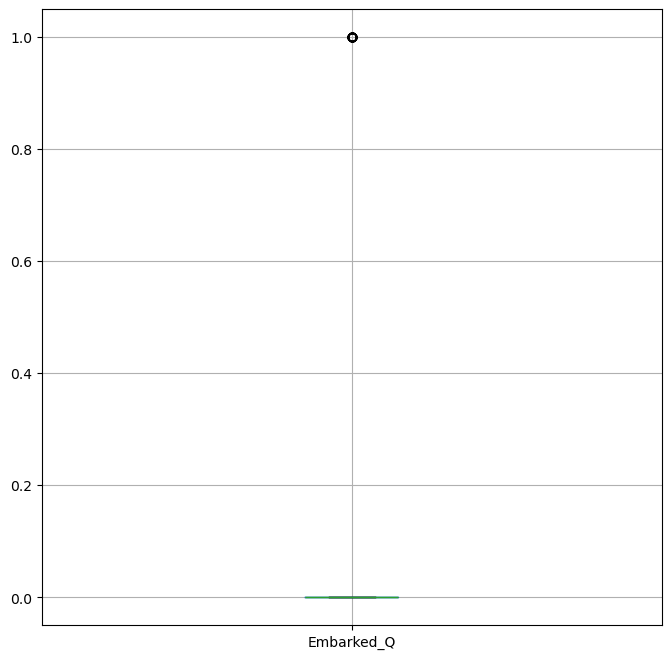

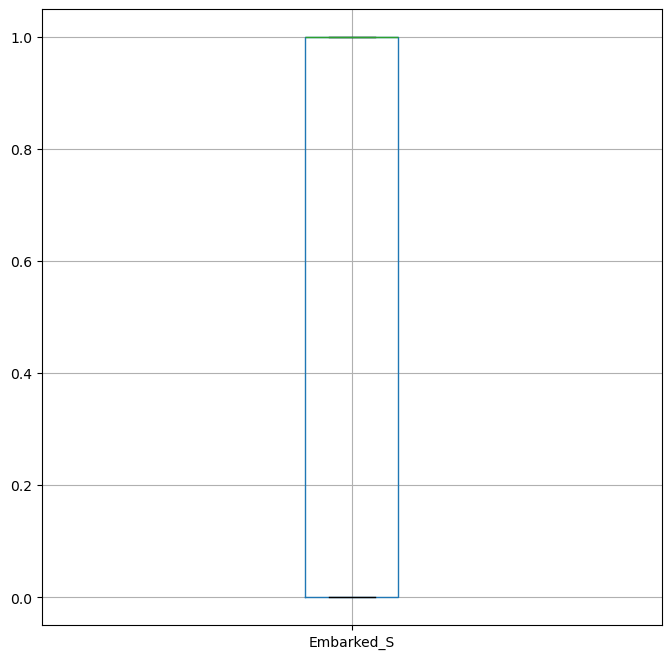

In [31]:
n=len(data_test_1.columns)
for i in range (0,n):
    plt.figure(figsize=[8,8])
    data_test_1.boxplot(column=[data_test_1.columns[i]])
    plt.show()

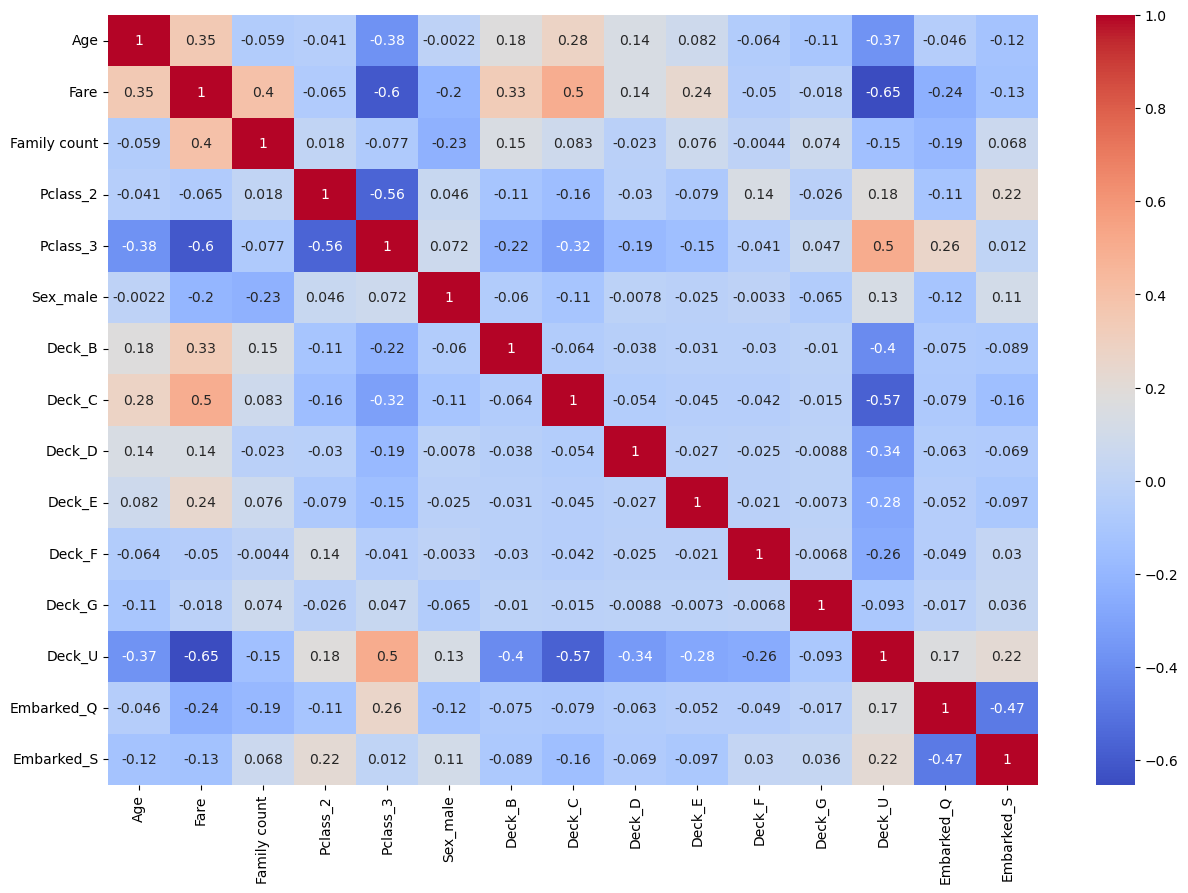

In [32]:
plt.figure(figsize=(15,10))
sns.heatmap(data_test_1.corr(),annot=True,cmap='coolwarm')
plt.show()

1.	Split the preprocessed dataset into training and testing sets.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X=data_train_1.drop(["Survived"], axis=1)
Y=data_train_1[["Survived"]]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)
X_scaled_df=pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled)

X_train,X_test,Y_train,Y_test=train_test_split(X_scaled_df,Y,test_size=0.3,random_state=42)
print(len(X_test))
print(len(X_train))
print(len(Y_test))
print(len(Y_train))

[[-0.58343208 -0.82055245  0.36668465 ...  0.54492498 -0.30756234
   0.61930636]
 [ 0.74268522  2.03162322  0.36668465 ... -1.835115   -0.30756234
  -1.61470971]
 [-0.25190275 -0.78757757 -0.72784139 ...  0.54492498 -0.30756234
   0.61930636]
 ...
 [-0.08613809 -0.02915533  2.00847372 ...  0.54492498 -0.30756234
   0.61930636]
 [-0.25190275  0.29082313 -0.72784139 ... -1.835115   -0.30756234
  -1.61470971]
 [ 0.24539123 -0.79612661 -0.72784139 ...  0.54492498  3.25137334
  -1.61470971]]
268
623
268
623


3.	Build predictive models using LightGBM and XGBoost algorithms.
4. Train the models on the training set and evaluate their performance on the testing set.

In [34]:
! pip install xgboost

In [35]:
! pip install lightgbm

In [36]:
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import lightgbm as lgb
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, Y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(Y_test, xgb_pred))
print(classification_report(Y_test,xgb_pred))

XGBoost Accuracy: 0.7873134328358209
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       157
           1       0.78      0.68      0.73       111

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.78       268
weighted avg       0.79      0.79      0.78       268



C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:29:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
 xgb_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0])

In [38]:
lgb_model = lgb.LGBMClassifier(verbose=-1)
lgb_model.fit(X_train, Y_train)
lgb_pred = lgb_model.predict(X_test)
print("LGBM Accuracy:", accuracy_score(Y_test, lgb_pred))
print(classification_report(Y_test,lgb_pred))

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


LGBM Accuracy: 0.7761194029850746
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       157
           1       0.75      0.68      0.72       111

    accuracy                           0.78       268
   macro avg       0.77      0.76      0.77       268
weighted avg       0.77      0.78      0.77       268



5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

In [39]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold

# 2. Define the XGBoost estimator
# Use a default instance for GridSearchCV to work with
xgb_model1 = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# 3. Define the parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

# 4. Set up the cross-validation scheme
# StratifiedKFold maintains the class distribution in each fold, useful for classification
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 5. Set up GridSearchCV
# scoring='roc_auc' is a common metric for binary classification
# n_jobs=-1 uses all available CPU cores for parallel processing
grid_search = GridSearchCV(
    estimator=xgb_model1, 
    param_grid=param_grid, 
    scoring='roc_auc', 
    n_jobs=-1, 
    cv=skf, 
    verbose=1
)

# 6. Fit the GridSearchCV to the data
# This performs the cross-validation and hyperparameter search
grid_search.fit(X_train, Y_train)

# 7. Print the best parameters and score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best ROC AUC score: {grid_search.best_score_:.4f}")

# 8. Use the best estimator to make predictions or save the model
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(predictions)

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters found: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best ROC AUC score: 0.8389
[0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 0 1 1 0 0 1 0 0 1
 1 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1
 0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 1 1 0 1 0 0 1 0 0]


C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:29:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [40]:
print(best_model)
print("Accuracy:", accuracy_score(Y_test, predictions))
print(classification_report(Y_test, predictions))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)
Accuracy: 0.7947761194029851
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       157
           1       0.79      0.69      0.74       111

    accuracy                    

In [41]:
lgb_model1 = lgb.LGBMClassifier(verbose=-1)

# 3. Define the parameter grid to search
param_grid_1 = {
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200]
}

# 4. Set up the cross-validation scheme
# StratifiedKFold maintains the class distribution in each fold, useful for classification
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 5. Set up GridSearchCV
# scoring='roc_auc' is a common metric for binary classification
# n_jobs=-1 uses all available CPU cores for parallel processing
grid_search1 = GridSearchCV(
    estimator=lgb_model1, 
    param_grid=param_grid_1, 
    scoring='roc_auc', 
    n_jobs=-1, 
    cv=skf, 
    verbose=1
)

# 6. Fit the GridSearchCV to the data
# This performs the cross-validation and hyperparameter search
grid_search1.fit(X_train, Y_train)

# 7. Print the best parameters and score
print(f"\nBest parameters found: {grid_search1.best_params_}")
print(f"Best ROC AUC score: {grid_search1.best_score_:.4f}")

# 8. Use the best estimator to make predictions or save the model
best_model1 = grid_search1.best_estimator_
predictions1 = best_model1.predict(X_test)
print(predictions1)

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters found: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200}
Best ROC AUC score: 0.8348
[0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1
 0 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 0 1 1 0 0 1 0 0 1
 1 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 0 0 1
 0 0 0 1 0 0 1 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 1 0 0 1 0 0]


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [42]:
print("Accuracy:", accuracy_score(Y_test, predictions1))
print(classification_report(Y_test, predictions1))

Accuracy: 0.7761194029850746
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       157
           1       0.75      0.68      0.72       111

    accuracy                           0.78       268
   macro avg       0.77      0.76      0.77       268
weighted avg       0.77      0.78      0.77       268



1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

* Model 1 xgbm (~79.5%): This model correctly predicted roughly 213 out of 268 passengers.
* Model 2 lgbm (~77.6%): This model correctly predicted roughly 208 out of 268 passengers.

The Difference: While a 2% gap seems small, in the Titanic competition, that jump can represent hundreds of places on the leaderboard.

* Class 1 is typically the harder class to predict because there are fewer survivors in the dataset.
* Precision (0.79 vs 0.75): In Model 1, when the model says someone survived, it is right 79% of the time. In Model 2, it drops to 75%. This means Model 2 is calling more people "Survivors" who actually perished (False Positives).
* Recall (0.69 vs 0.68): Both models struggle to find all the survivors (missing about 31-32% of them), but Model 1 still has a slight edge.
  
* Since Class 0 has a higher support (157 passengers), it acts as the "anchor" for your accuracy.
* Model 1 has a significantly better F1-score (0.83 vs 0.81) for the deceased. It is much better at identifying the patterns of those who didn't make it, which likely includes the "Male + 3rd Class" demographic.

* The fact that Precision, Recall, and F1-score are all higher in Model 1 suggests that the hyperparameter tuning done helped it find a more general rule for survival. Model 2 is slightly more "noisy"—it's making more mistakes on both sides of the coin.

Confusion Matrix as a NumPy array:
 [[136  21]
 [ 34  77]]


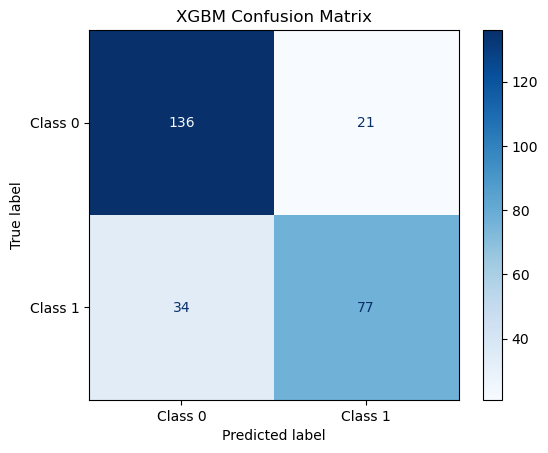

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = [0, 1]
cm = confusion_matrix(Y_test, predictions, labels=labels)
print("Confusion Matrix as a NumPy array:\n", cm)

# 3. Visualize the confusion matrix using ConfusionMatrixDisplay
# This is the recommended method in recent scikit-learn versions
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title('XGBM Confusion Matrix')
plt.show()

Confusion Matrix as a NumPy array:
 [[132  25]
 [ 35  76]]


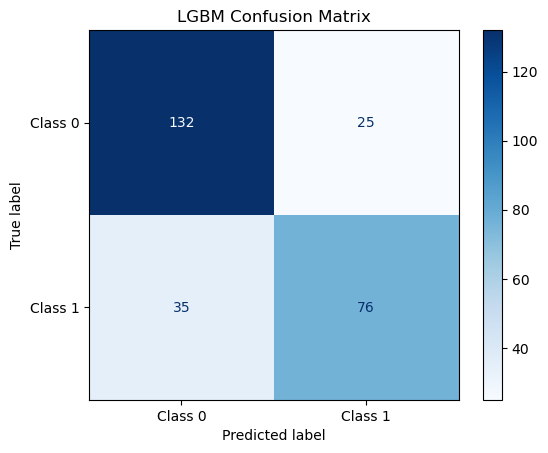

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = [0, 1]
cm = confusion_matrix(Y_test, predictions1, labels=labels)
print("Confusion Matrix as a NumPy array:\n", cm)

# 3. Visualize the confusion matrix using ConfusionMatrixDisplay
# This is the recommended method in recent scikit-learn versions
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title('LGBM Confusion Matrix')
plt.show()

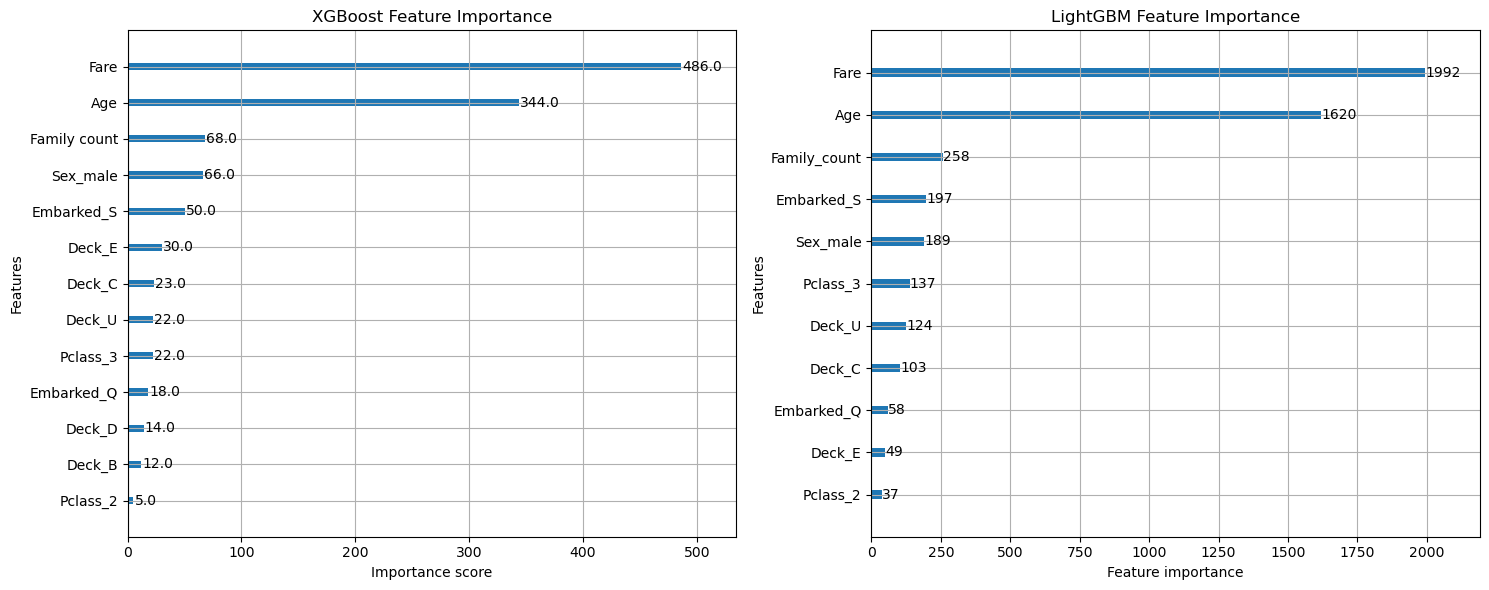

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
xgb.plot_importance(best_model, ax=ax[0], title='XGBoost Feature Importance')
lgb.plot_importance(best_model1, ax=ax[1], title='LightGBM Feature Importance')
plt.tight_layout()
plt.show()


XGBoost: Level-wise Growth (Conservative)
* XGBoost grows trees level-wise (layer by layer). 
* It completes an entire level of nodes before moving deeper.
* Strength: This acts as a form of regularization. By keeping the tree "balanced," it avoids digging too deep into a specific branch that might just be "noise" or a coincidence in the data.
* Weakness: It is slower because it has to calculate splits for every node in a level, even if some don't significantly reduce the loss.

LightGBM: Leaf-wise Growth (Aggressive)
* LightGBM grows trees leaf-wise. 
* It chooses the specific leaf that will reduce the "loss" the most and splits it, regardless of what level it is on.
* Strength: It is incredibly fast and can find complex, high-accuracy patterns in large datasets.
* Weakness: On small datasets like the Titanic (only ~891 rows), it tends to overfit. It might create a very deep, narrow branch that perfectly describes 3 specific people in the training data but fails to predict anyone else correctly. This explains why its precision dropped to 0.75 in the results.

In [46]:
data_test_1.insert(loc=12, column='Deck_T', value=0)
data_test_1

,Age,Fare,Family count,Pclass_2,Pclass_3,Sex_male,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Embarked_Q,Embarked_S
0,34.500,7.829200,1.0,0,1,1,0,0,0,0,0,0,0,1,1,0
1,47.000,7.000000,2.0,0,1,0,0,0,0,0,0,0,0,1,0,1
2,54.875,9.687500,1.0,1,0,1,0,0,0,0,0,0,0,1,1,0
3,27.000,8.662500,1.0,0,1,1,0,0,0,0,0,0,0,1,0,1
4,22.000,12.287500,3.0,0,1,0,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,27.000,8.050000,1.0,0,1,1,0,0,0,0,0,0,0,1,0,1
414,39.000,66.835988,1.0,0,0,0,0,1,0,0,0,0,0,0,0,0
415,38.500,7.250000,1.0,0,1,1,0,0,0,0,0,0,0,1,0,1
416,27.000,8.050000,1.0,0,1,1,0,0,0,0,0,0,0,1,0,1


In [47]:
#final_preds = best_model.predict(data_test_1) # Using LightGBM as it often performs better
#submission = pd.DataFrame({'Survived': final_preds})
#submission.to_csv('Titanic_Final_Predictions.csv', index=False)
#print("Final predictions saved to Titanic_Final_Predictions.csv")